# Notebook 02 — Data Cleaning & Feature Engineering
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D2 — Cleaned Datasets  

## Table of Contents
1. Setup & Chargement
2. Nettoyage Plaintes (Sheet1)
3. Nettoyage KPI
4. Feature Engineering
5. Train/Test Split
6. Sauvegarde & Checklist

## 1. Setup & Chargement

In [2]:
# ── Notebook 02 — Data Cleaning & Feature Engineering ─────────────────────
# Deliverable : D2 — Cleaned Datasets + Feature Matrix
# Inputs      : real_complaints.xlsx · dataCollectionist.csv
# Outputs     : data/processed/*.parquet (5 files)

import sys, os
from pathlib import Path

# ── Project root ───────────────────────────────────────────────────────────
PROJECT_ROOT = r'C:\Users\c50057188\Desktop\PFE_Ouerghi'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

# ── Core libraries ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Jupyter display ────────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    'figure.dpi':       120,
    'figure.figsize':   (12, 5),
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
sns.set_theme(style='darkgrid', palette='husl')

# ── Color palette (consistent with Notebook 01) ───────────────────────────
COLORS     = sns.color_palette('husl', 10)
HUAWEI_RED = '#CF0A2C'
C_DATA     = '#1A73E8'
C_VOICE    = '#E74C3C'
C_NEUTRAL  = '#6B7280'

# ── Output directories ─────────────────────────────────────────────────────
FIGURES   = Path('reports/figures')
EXPORTS   = Path('reports/exports')
PROCESSED = Path('data/processed')
for d in [FIGURES, EXPORTS, PROCESSED]:
    d.mkdir(parents=True, exist_ok=True)

print('  Setup complete')
print(f'   pandas   {pd.__version__}')
print(f'   numpy    {np.__version__}')
print(f'   Project → {PROJECT_ROOT}')

  Setup complete
   pandas   2.3.3
   numpy    2.3.5
   Project → C:\Users\c50057188\Desktop\PFE_Ouerghi


In [3]:
# ── Cellule 2 — Data Loading ───────────────────────────────────────────────
from src.ingestion.real_data_loader import load_all_from_excel
from src.ingestion.data_collectionist_loader import load_collectionist

# ── Tunisia MSISDN operator inference (same as Notebook 01) ───────────────
def infer_operator(msisdn_series: pd.Series) -> pd.Series:
    local  = (msisdn_series.astype(str)
              .str.replace(r'^(00216|\+216|216)', '', regex=True)
              .str.strip())
    p2 = local.str[:2]
    p1 = local.str[:1]
    op = pd.Series('Unknown', index=msisdn_series.index)
    op[p2.str.match(r'^2\d$') | p2.str.match(r'^5[0-8]$')]          = 'Ooredoo'
    op[p2.str.match(r'^9\d$') | p2.isin(['40','41','42','44','46'])] = 'TunisieTelecom'
    op[local.between('43000000','43009999')]                          = 'Orange'
    op[(p1 == '3') & (op == 'Unknown')]                               = 'Ooredoo'
    op[(p1 == '7') & (op == 'Unknown')]                               = 'TunisieTelecom'
    op[(p1 == '4') & (op == 'Unknown')]                               = 'TunisieTelecom'
    return op

# ── 1. real_complaints.xlsx — Sheet1 ──────────────────────────────────────
data           = load_all_from_excel()
complaints_raw = data['complaints']
complaints_raw['operator'] = infer_operator(complaints_raw['msisdn'])
complaints_raw['msisdn']   = (complaints_raw['msisdn'].astype(str)
                               .str.replace(r'\.0$', '', regex=True)
                               .str.strip())

# ── 2. dataCollectionist.csv — real network KPI ────────────────────────────
# This replaces synthetic_kpi.parquet entirely.
# 4,898 subscribers · snapshot 2026-03-13 · 67 real KPI columns
dc = load_collectionist('data/raw/dataCollectionist.csv')
dc['operator']   = infer_operator(dc['msisdn'])
dc['region_join'] = (dc['LAYER2NAME'].astype(str)
                      .str.strip().str.title()
                      .replace({
                          'Beja Gouvernorat':       'Béja Gouvernorat',
                          'Gabes Gouvernorat':      'Gabès Gouvernorat',
                          'Medenine Gouvernorat':   'Mednine Gouvernorat',
                          'Sidi_Bouzid Gouvernorat':'Sidi Bouzid Gouvernorat',
                          'Zaghouen Gouvernorat':   'Zaghouan Gouvernorat',
                      }))
dc['region'] = (dc['LAYER2NAME'].astype(str).str.strip().str.title())

# Real KPI columns (from Notebook 01 categorisation)
COLS_KPI_NETWORK = [c for c in [
    'e2e_delay_ms', 'client_rtt_ms', 'server_rtt_ms',
    'Client_Packet_Loss_Rate', 'SERVER_Packet_Loss_Rate',
    'TCP_connection_sr', 'SYN_ACK_ACK_delay', 'SYN_SYN_ACK_delay',
    'Https_Handshake_Success_Rate', 'dns_delay', 'DNS_SR',
    'UDP_Uplink_Packet_Intervals_ms', 'UDP_Downlink_Packet_Intervals_ms',
    'UDP_Uplink_Jitter', 'UDP_Downlink_Jitter',
    'QUIC_Uplink_Packet_Loss_Rate', 'QUIC_Downlink_Packet_Loss_Rate',
    'QUIC_Uplink_Out_of_Order_Rate', 'QUIC_Downlink_Out_of_Order_Rate',
] if c in dc.columns]

COLS_KPI_VIDEO = [c for c in [
    'video_streaming_download_throughput', 'Video_xkb_start_delay',
    'Video_Streaming_Start_Success_Rate', 'Video_Streaming_Start_Delay',
    'Video_Streaming_Stall_Frequency',
] if c in dc.columns]

COLS_KPI_SIGNALLING = [c for c in [
    'E_RAB_SR', 'S1_MME_SR', 'S1_MME_Auth_SR',
    'S1_MME_DF_EPS_Bearer_Context_Activation_SR',
    'Iu_Attach_SR', 'IU_PDP_Context_Procedure_Activation_SR',
    'IU_Paging_SR', 'IU_Auth_ciphering_SR',
    'Gb_Attach_SR', 'GB_PDP_Context_Procedure_Activation_SR',
    'GB_Paging_SR', 'GB_Auth_ciphering_SR',
    'S6a_Auth_Info_Obtai_SR', 'S6a_update_location_SR',
    'CCR_I', 'CCR_U', 'CCR_I_GX', 'CCR_U_GX',
    'Gr_Send_Authentication_Information_SR', 'Gr_Update_Location_SR',
    'S5_S8_Default_Bearer_Creation_SR', 'S3S10Context_SR',
    'GnGpCreate_PDP_Context_Procedure_SR',
    'SGs_Location_Update_Success_Rate', 'SGs_Paging_Success_Rate',
    'SGs_SMS_Origination_Success_Rate', 'SGs_SMS_Termination_Success_Rate',
] if c in dc.columns]

COLS_KPI_WEB  = [c for c in [
    'Page_Response_Success_Rate', 'Page_Response_Delay',
    'Page_Browsing_Success_Rate', 'Page_Browsing_Delay',
    'Page_Download_Throughput',
] if c in dc.columns]

COLS_KPI_VOIP = [c for c in [
    'VoIP_Voice_Uplink_Throughput', 'VoIP_Voice_Downlink_Throughput',
    'VoIP_Video_Uplink_Throughput', 'VoIP_Video_Downlink_Throughput',
    'IM_interactive_delay',
] if c in dc.columns]

COLS_KPI_ALL = (COLS_KPI_NETWORK + COLS_KPI_VIDEO +
                COLS_KPI_WEB + COLS_KPI_VOIP + COLS_KPI_SIGNALLING)

# Exclude unreliable KPIs (>75% nulls from Notebook 01 analysis)
COLS_KPI_UNRELIABLE = {
    'QUIC_Uplink_Packet_Loss_Rate',    # 89% nulls
    'QUIC_Downlink_Packet_Loss_Rate',  # 76% nulls
    'QUIC_Uplink_Out_of_Order_Rate',   # 88% nulls
    'QUIC_Downlink_Out_of_Order_Rate', # 76% nulls
    'E_RAB_SR',                        # 99% nulls
    'GB_PDP_Context_Procedure_Activation_SR', # 92% nulls
    'Page_Browsing_Success_Rate',      # 93% nulls
    'Page_Browsing_Delay',             # 94% nulls
    'SGs_SMS_Origination_Success_Rate',# 94% nulls
}
COLS_KPI_RELIABLE = [c for c in COLS_KPI_ALL
                     if c not in COLS_KPI_UNRELIABLE]

# ── Overview ───────────────────────────────────────────────────────────────
print('=' * 58)
print('  INPUTS — NOTEBOOK 02')
print('=' * 58)
print(f'  complaints_raw   : {complaints_raw.shape[0]:>8,} × {complaints_raw.shape[1]} cols')
print(f'  dataCollectionist: {dc.shape[0]:>8,} × {dc.shape[1]} cols')
print(f'    KPI total cols : {len(COLS_KPI_ALL)}')
print(f'    KPI reliable   : {len(COLS_KPI_RELIABLE)} (excluded {len(COLS_KPI_UNRELIABLE)} high-null)')
print()
print(f'  Complaints period: {complaints_raw["timestamp"].min().date()} → '
      f'{complaints_raw["timestamp"].max().date()}')
print(f'  dc snapshot date : 2026-03-13  (single day)')
print()
print('  Complaints operator split:')
for op, cnt in complaints_raw['operator'].value_counts().items():
    print(f'    {op:<22} {cnt:>7,}  ({cnt/len(complaints_raw)*100:.1f}%)')
print()
print('  dc operator split:')
for op, cnt in dc['operator'].value_counts().items():
    print(f'    {op:<22} {cnt:>6,}  ({cnt/len(dc)*100:.1f}%)')
print('=' * 58)

2026-05-14 08:55:39.207 | INFO     | src.ingestion.real_data_loader:load_all_from_excel:174 - Loading: data\raw\real_complaints.xlsx
2026-05-14 08:55:41.465 | INFO     | src.ingestion.real_data_loader:load_all_from_excel:177 -   Sheets found: ['Sheet1', 'DATA', 'VOICE']
2026-05-14 08:55:48.183 | INFO     | src.ingestion.real_data_loader:_load_sheet1:267 -   Sheet1 ('Sheet1'): 25,727 rows × 17 cols
2026-05-14 08:55:48.188 | DEBUG    | src.ingestion.real_data_loader:_load_sheet1:270 -   Raw columns: ['Case ID', 'system', 'case open datetime', 'Type', 'msisdn', 'last status', 'Provider Group', 'typologie It/network', 'category', 'sub category', 'sub sub category', 'province', 'city', 'Segment MSISDN CONCERN', 'bscs_custcode', 'account contact name', 'Week']
2026-05-14 08:55:48.221 | INFO     | src.ingestion.real_data_loader:_apply_mapping:625 -   Dropped (GDPR): ['account contact name']
2026-05-14 08:55:48.231 | INFO     | src.ingestion.real_data_loader:_apply_mapping:628 -   16 columns r

  INPUTS — NOTEBOOK 02
  complaints_raw   :   25,727 × 23 cols
  dataCollectionist:    4,898 × 130 cols
    KPI total cols : 61
    KPI reliable   : 52 (excluded 9 high-null)

  Complaints period: 2025-01-01 → 2025-12-03
  dc snapshot date : 2026-03-13  (single day)

  Complaints operator split:
    Ooredoo                 24,310  (94.5%)
    TunisieTelecom           1,327  (5.2%)
    Unknown                     90  (0.3%)

  dc operator split:
    TunisieTelecom          4,367  (89.2%)
    Ooredoo                   529  (10.8%)
    Unknown                     2  (0.0%)


## 2. Nettoyage Plaintes (Sheet1)

In [10]:
# ── Cellule 3 — Complaint Cleaning ────────────────────────────────────────
from src.processing.real_complaint_cleaner import clean_complaints, print_cleaning_report

complaints_clean, report = clean_complaints(complaints_raw)
print_cleaning_report(report)

2026-05-14 09:00:41.295 | INFO     | src.processing.real_complaint_cleaner:clean_complaints:125 - Starting complaint cleaning pipeline — 25,727 rows


2026-05-14 09:00:41.374 | INFO     | src.processing.real_complaint_cleaner:_remove_duplicates:193 -   Dedup: 0 duplicates removed
2026-05-14 09:00:41.439 | WARNING  | src.processing.real_complaint_cleaner:_standardise_categories:226 -   25727 complaints with unrecognised category → 'Other'
2026-05-14 09:00:41.443 | INFO     | src.processing.real_complaint_cleaner:_standardise_categories:238 -   Categories: 25727 unknowns relabelled
2026-05-14 09:00:41.466 | INFO     | src.processing.real_complaint_cleaner:_standardise_service_types:275 -   Service types: 0 unknowns processed
2026-05-14 09:00:41.467 | INFO     | src.processing.real_complaint_cleaner:_clean_geographic:306 -   Geo: no lat/lon columns — skipping (real DCLM data)
2026-05-14 09:00:41.497 | INFO     | src.processing.real_complaint_cleaner:_clean_temporal:373 -   Temporal: 0 future + 0 pre-2015 rows removed
2026-05-14 09:00:41.526 | INFO     | src.processing.real_complaint_cleaner:_impute_missing:408 -   Imputation: 5 columns 


  COMPLAINT CLEANING REPORT
  Input rows        :     25,727
  Output rows       :     25,727
  Rows removed      :          0  (0.0%)
  Output columns    :         26
  Remaining nulls   :     30,613

  Step Details:

  [debug_cols_dropped]
    []

  [duplicates]
    exact_row_duplicates_removed        : 0
    case_id_duplicates_removed          : 0
    total_removed                       : 0

  [category_fixes]
    aliases_applied                     : 27
    unknown_relabelled                  : 25727

  [service_fixes]
    aliases_applied                     : 9
    n_unknown_processed                 : 0
    final_unknown_count                 : 0

  [geo]
    status                              : no_geo_columns

  [temporal]
    future_timestamps_removed           : 0
    pre_2015_timestamps_removed         : 0
    total_removed                       : 0

  [imputation]

  [ordinal_encoded]
    ['priority_encoded', 'segment_encoded']



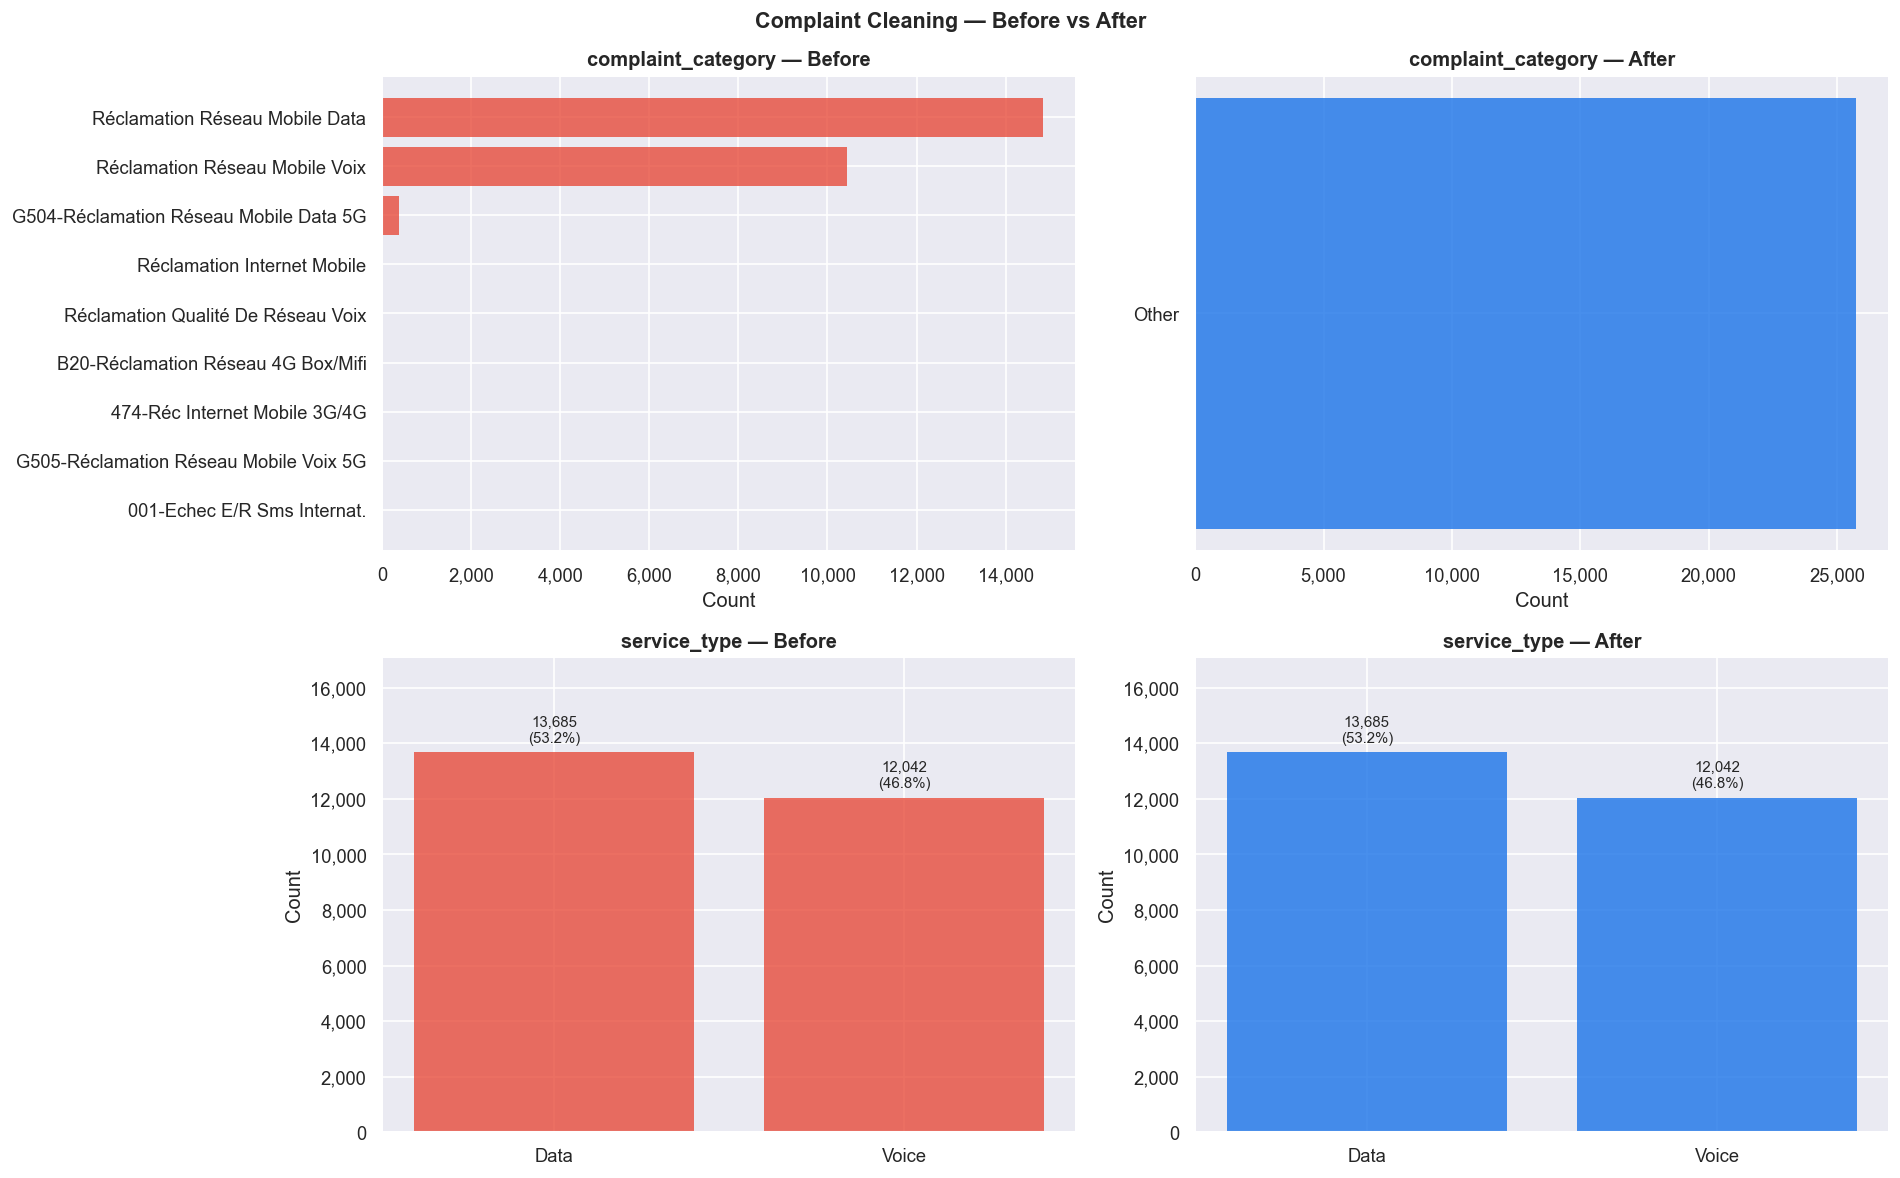

Rows before : 25,727
Rows after  : 25,727
Removed     : 0  (0.00%)
Columns     : 23 → 26

New columns added by cleaner:
  data_quality_flag
  priority_encoded
  segment_encoded


In [11]:
# ── Cellule 4 — Complaint Cleaning : Before / After visualisation ──────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── 1. complaint_category before / after ──────────────────────────────────
vc_b = (complaints_raw['complaint_category']
        .value_counts().head(10).sort_values())
vc_a = (complaints_clean['complaint_category']
        .value_counts().head(10).sort_values())

axes[0,0].barh(vc_b.index, vc_b.values,
               color=C_VOICE, alpha=0.8, edgecolor='none')
axes[0,0].set_title('complaint_category — Before', fontweight='bold')
axes[0,0].set_xlabel('Count')
axes[0,0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[0,1].barh(vc_a.index, vc_a.values,
               color=C_DATA, alpha=0.8, edgecolor='none')
axes[0,1].set_title('complaint_category — After', fontweight='bold')
axes[0,1].set_xlabel('Count')
axes[0,1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── 2. service_type before / after ────────────────────────────────────────
svc_b = complaints_raw['service_type'].value_counts()
svc_a = complaints_clean['service_type'].value_counts()

for ax, vc, title, color in [
    (axes[1,0], svc_b, 'service_type — Before', C_VOICE),
    (axes[1,1], svc_a, 'service_type — After',  C_DATA),
]:
    bars = ax.bar(vc.index, vc.values,
                  color=color, alpha=0.8, edgecolor='none')
    ax.bar_label(bars,
                 labels=[f'{v:,}\n({v/vc.sum()*100:.1f}%)'
                          for v in vc.values],
                 padding=4, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, vc.max() * 1.25)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Complaint Cleaning — Before vs After',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'cleaning_complaint_before_after.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary delta ──────────────────────────────────────────────────────────
print(f'Rows before : {len(complaints_raw):,}')
print(f'Rows after  : {len(complaints_clean):,}')
print(f'Removed     : {len(complaints_raw)-len(complaints_clean):,}  '
      f'({(len(complaints_raw)-len(complaints_clean))/len(complaints_raw)*100:.2f}%)')
print(f'Columns     : {complaints_raw.shape[1]} → {complaints_clean.shape[1]}')
print()
print('New columns added by cleaner:')
new_cols = set(complaints_clean.columns) - set(complaints_raw.columns)
for c in sorted(new_cols):
    print(f'  {c}')

In [12]:
# ── Cellule 5 — Complaints Clean : Validation ─────────────────────────────

# ── 1. Service type breakdown ──────────────────────────────────────────────
print('Service type (inferred from DCLM sub category):')
for svc, cnt in complaints_clean['service_type'].value_counts().items():
    print(f'  {svc:<15} {cnt:>8,}  ({cnt/len(complaints_clean)*100:.1f}%)')

# ── 2. Operator split (preserved from raw) ────────────────────────────────
if 'operator' in complaints_clean.columns:
    print('\nOperator split:')
    for op, cnt in complaints_clean['operator'].value_counts().items():
        print(f'  {op:<22} {cnt:>7,}  ({cnt/len(complaints_clean)*100:.1f}%)')

# ── 3. Temporal validation ─────────────────────────────────────────────────
print(f'\nPeriod   : {complaints_clean["timestamp"].min().date()} → '
      f'{complaints_clean["timestamp"].max().date()}')
print(f'Rows     : {len(complaints_clean):,}')
print(f'Columns  : {complaints_clean.shape[1]}')

# ── 4. GDPR check ─────────────────────────────────────────────────────────
gdpr_cols = ['account contact name', 'account_contact_name',
             'imsi', 'bscs_custcode', 'customer_code']
print('\nGDPR check:')
for col in gdpr_cols:
    present = col in complaints_clean.columns
    status  = '✗ PRESENT — review' if present else '✓ absent'
    print(f'  {col:<30} {status}')

# ── 5. Null check ─────────────────────────────────────────────────────────
print('\nNull values after cleaning:')
nulls = complaints_clean.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
if nulls.empty:
    print('  ✓ No null values remaining')
else:
    for col, cnt in nulls.items():
        pct = cnt / len(complaints_clean) * 100
        flag = '  ⚠' if pct > 5 else ''
        print(f'  {col:<40} {cnt:>6,}  ({pct:.1f}%){flag}')

# ── 6. New columns added by cleaner ───────────────────────────────────────
new_cols = sorted(set(complaints_clean.columns) - set(complaints_raw.columns))
print(f'\nNew columns added ({len(new_cols)}):')
for c in new_cols:
    dtype = str(complaints_clean[c].dtype)
    sample = str(complaints_clean[c].iloc[0])[:25]
    print(f'  {c:<35} dtype={dtype:<10} sample={sample}')

# ── 7. Priority distribution ──────────────────────────────────────────────
if 'priority' in complaints_clean.columns:
    print('\nPriority distribution (derived from customer_segment):')
    for pri, cnt in complaints_clean['priority'].value_counts().items():
        print(f'  {pri:<12} {cnt:>7,}  ({cnt/len(complaints_clean)*100:.1f}%)')

# ── 8. Data quality flag ──────────────────────────────────────────────────
if 'data_quality_flag' in complaints_clean.columns:
    n_flagged = int(complaints_clean['data_quality_flag'].sum())
    print(f'\nData quality flags : {n_flagged:,}  '
          f'({n_flagged/len(complaints_clean)*100:.1f}% of records)')

Service type (inferred from DCLM sub category):
  Data              13,685  (53.2%)
  Voice             12,042  (46.8%)

Operator split:
  Ooredoo                 24,310  (94.5%)
  TunisieTelecom           1,327  (5.2%)
  Unknown                     90  (0.3%)

Period   : 2025-01-01 → 2025-12-03
Rows     : 25,727
Columns  : 26

GDPR check:
  account contact name           ✓ absent
  account_contact_name           ✓ absent
  imsi                           ✓ absent
  bscs_custcode                  ✓ absent
  customer_code                  ✗ PRESENT — review

Null values after cleaning:
  week                                     25,727  (100.0%)  ⚠
  city                                      2,511  (9.8%)  ⚠
  region                                    2,375  (9.2%)  ⚠

New columns added (3):
  data_quality_flag                   dtype=int64      sample=1
  priority_encoded                    dtype=int64      sample=2
  segment_encoded                     dtype=int64      sample=1

Priorit

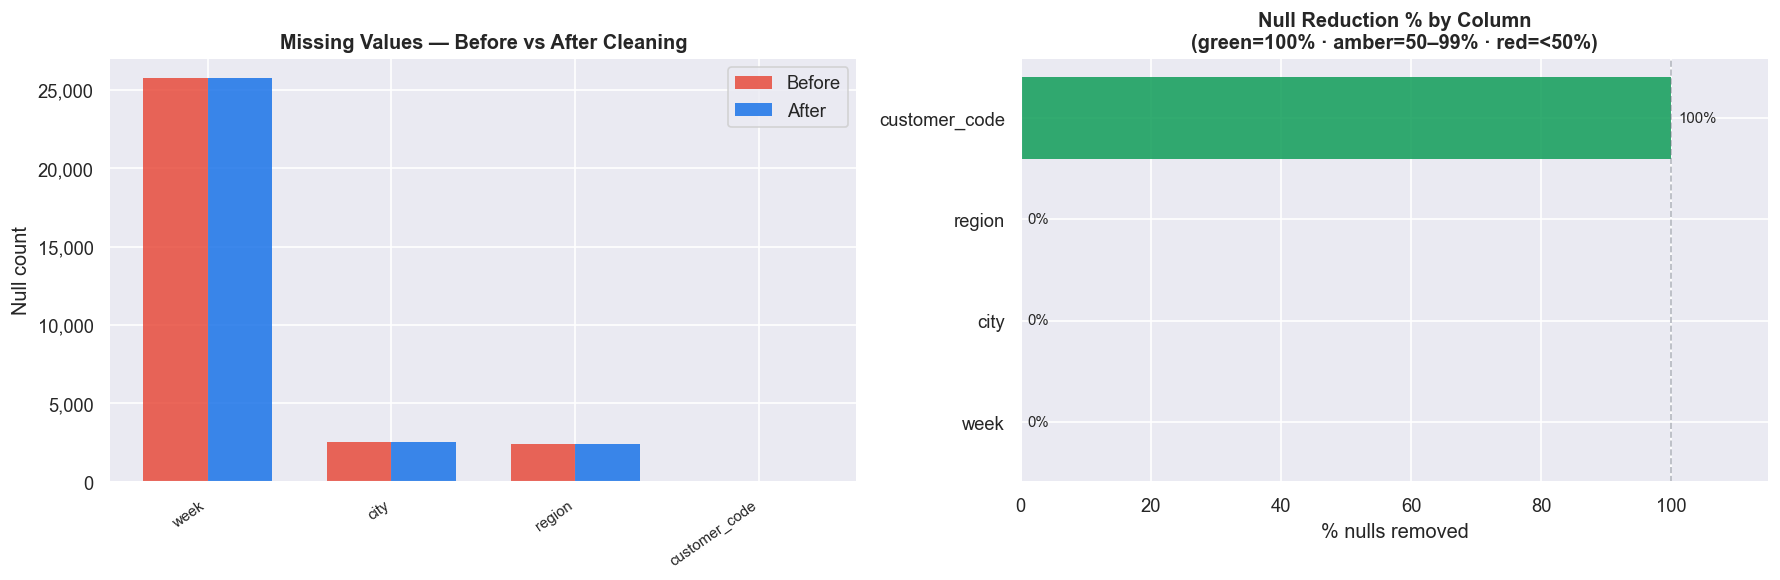

Columns with nulls : 4

  Column                                     Before    After  Reduction
  ---------------------------------------- -------- -------- ----------
  week                                     25,727.0 25,727.0         0%
  city                                      2,511.0  2,511.0         0%
  region                                    2,375.0  2,375.0         0%
  customer_code                                 3.0      0.0       100%


In [13]:
# ── Cellule 6 — Missing Values : Before vs After ───────────────────────────

missing_before = complaints_raw.isnull().sum()
missing_after  = complaints_clean.isnull().sum()

# Only show columns that had nulls in at least one version
comparison = pd.DataFrame({
    'Before': missing_before,
    'After':  missing_after,
})
comparison = comparison[comparison.sum(axis=1) > 0].sort_values('Before',
                                                                  ascending=False)

if comparison.empty:
    print('✓ No missing values in either raw or clean dataset')
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ── 1. Grouped bar — Before vs After ──────────────────────────────────
    x     = np.arange(len(comparison))
    w     = 0.35
    bars1 = axes[0].bar(x - w/2, comparison['Before'],
                         w, color=C_VOICE, alpha=0.85,
                         label='Before', edgecolor='none')
    bars2 = axes[0].bar(x + w/2, comparison['After'],
                         w, color=C_DATA, alpha=0.85,
                         label='After', edgecolor='none')

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(comparison.index, rotation=35, ha='right', fontsize=9)
    axes[0].set_title('Missing Values — Before vs After Cleaning',
                       fontweight='bold')
    axes[0].set_ylabel('Null count')
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # ── 2. % reduction bar ────────────────────────────────────────────────
    reduction = ((comparison['Before'] - comparison['After'])
                  / comparison['Before'].replace(0, np.nan) * 100
                  ).fillna(0).sort_values(ascending=True)

    colors_red = ['#0F9D58' if v == 100 else
                  '#F59E0B' if v >= 50  else
                  '#CF0A2C'
                  for v in reduction.values]

    bars3 = axes[1].barh(reduction.index, reduction.values,
                          color=colors_red, edgecolor='none', alpha=0.85)
    axes[1].bar_label(bars3,
                      labels=[f'{v:.0f}%' for v in reduction.values],
                      padding=4, fontsize=9)
    axes[1].axvline(100, color=C_NEUTRAL, linestyle='--',
                    linewidth=1, alpha=0.5)
    axes[1].set_xlim(0, 115)
    axes[1].set_title('Null Reduction % by Column\n'
                       '(green=100% · amber=50–99% · red=<50%)',
                       fontweight='bold')
    axes[1].set_xlabel('% nulls removed')

    plt.tight_layout()
    plt.savefig(FIGURES / 'cleaning_missing_before_after.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────────
    print(f'Columns with nulls : {len(comparison)}')
    print(f'\n  {"Column":<40} {"Before":>8} {"After":>8} {"Reduction":>10}')
    print(f'  {"-"*40} {"-"*8} {"-"*8} {"-"*10}')
    for col, row in comparison.iterrows():
        red = (row["Before"] - row["After"]) / max(row["Before"], 1) * 100
        print(f'  {col:<40} {row["Before"]:>8,} {row["After"]:>8,} '
              f'{red:>9.0f}%')

Priority derived from customer_segment:
  Segment                   Priority      Encoded
  ------------------------- ------------ --------
  Premium                   Medium              2
  Lowenduser                Medium              2
  Hv                        Medium              2
  Vlv                       Medium              2
  Mv                        Medium              2
  Highenduser               Medium              2
  Unknown                   Medium              2
  Lv                        Medium              2
  Entreprise                Medium              2

Segment ordinal encoding:
  Lowenduser           encoded=-1  n=  3,563  (13.8%)
  Hv                   encoded=-1  n=  5,388  (20.9%)
  Vlv                  encoded=-1  n=  1,686  (6.6%)
  Mv                   encoded=-1  n=  3,361  (13.1%)
  Unknown              encoded=-1  n=  2,107  (8.2%)
  Highenduser          encoded=-1  n=  7,783  (30.3%)
  Lv                   encoded=-1  n=  1,802  (7.0%)
  Entrep

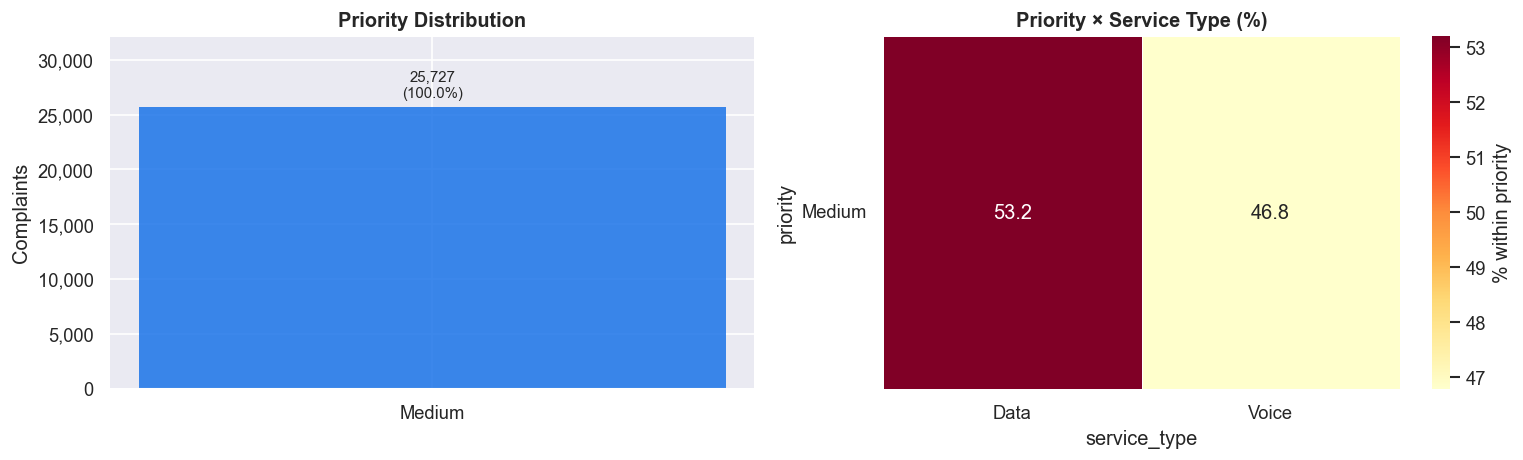

In [14]:
# ── Cellule 7 — Priority & Segment Encoding Validation ────────────────────

# ── 1. Priority × Segment mapping ─────────────────────────────────────────
print('Priority derived from customer_segment:')
print(f'  {"Segment":<25} {"Priority":<12} {"Encoded":>8}')
print(f'  {"-"*25} {"-"*12} {"-"*8}')

mapping = (complaints_clean[['customer_segment', 'priority', 'priority_encoded']]
           .drop_duplicates()
           .sort_values('priority_encoded'))

for _, row in mapping.iterrows():
    print(f'  {str(row["customer_segment"]):<25} '
          f'{str(row["priority"]):<12} '
          f'{int(row["priority_encoded"]):>8}')

# ── 2. Segment encoding ────────────────────────────────────────────────────
if 'segment_encoded' in complaints_clean.columns:
    print('\nSegment ordinal encoding:')
    seg_map = (complaints_clean[['customer_segment', 'segment_encoded']]
               .drop_duplicates()
               .sort_values('segment_encoded'))
    for _, row in seg_map.iterrows():
        cnt = (complaints_clean['customer_segment'] == row['customer_segment']).sum()
        pct = cnt / len(complaints_clean) * 100
        print(f'  {str(row["customer_segment"]):<20} '
              f'encoded={int(row["segment_encoded"])}  '
              f'n={cnt:>7,}  ({pct:.1f}%)')

# ── 3. Priority distribution visualisation ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar — priority count
pri_counts = complaints_clean['priority'].value_counts()
pri_order  = ['Critical', 'High', 'Medium', 'Low']
pri_colors = {'Critical': '#CF0A2C', 'High': '#F59E0B',
              'Medium':   C_DATA,    'Low':  '#0F9D58'}
pri_ordered = pri_counts.reindex(
    [p for p in pri_order if p in pri_counts.index]
)
bars = axes[0].bar(
    pri_ordered.index, pri_ordered.values,
    color=[pri_colors[p] for p in pri_ordered.index],
    edgecolor='none', alpha=0.85
)
axes[0].bar_label(bars,
                  labels=[f'{v:,}\n({v/len(complaints_clean)*100:.1f}%)'
                           for v in pri_ordered.values],
                  padding=4, fontsize=9)
axes[0].set_title('Priority Distribution', fontweight='bold')
axes[0].set_ylabel('Complaints')
axes[0].set_ylim(0, pri_ordered.max() * 1.25)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Heatmap — Priority × Service Type
if 'service_type' in complaints_clean.columns:
    ct = pd.crosstab(complaints_clean['priority'],
                     complaints_clean['service_type'],
                     normalize='index').mul(100).round(1)
    ct = ct.reindex([p for p in pri_order if p in ct.index])
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.3, ax=axes[1],
                cbar_kws={'label': '% within priority'})
    axes[1].set_title('Priority × Service Type (%)', fontweight='bold')
    axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / 'cleaning_priority_segment.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3. Nettoyage KPI Synthétique

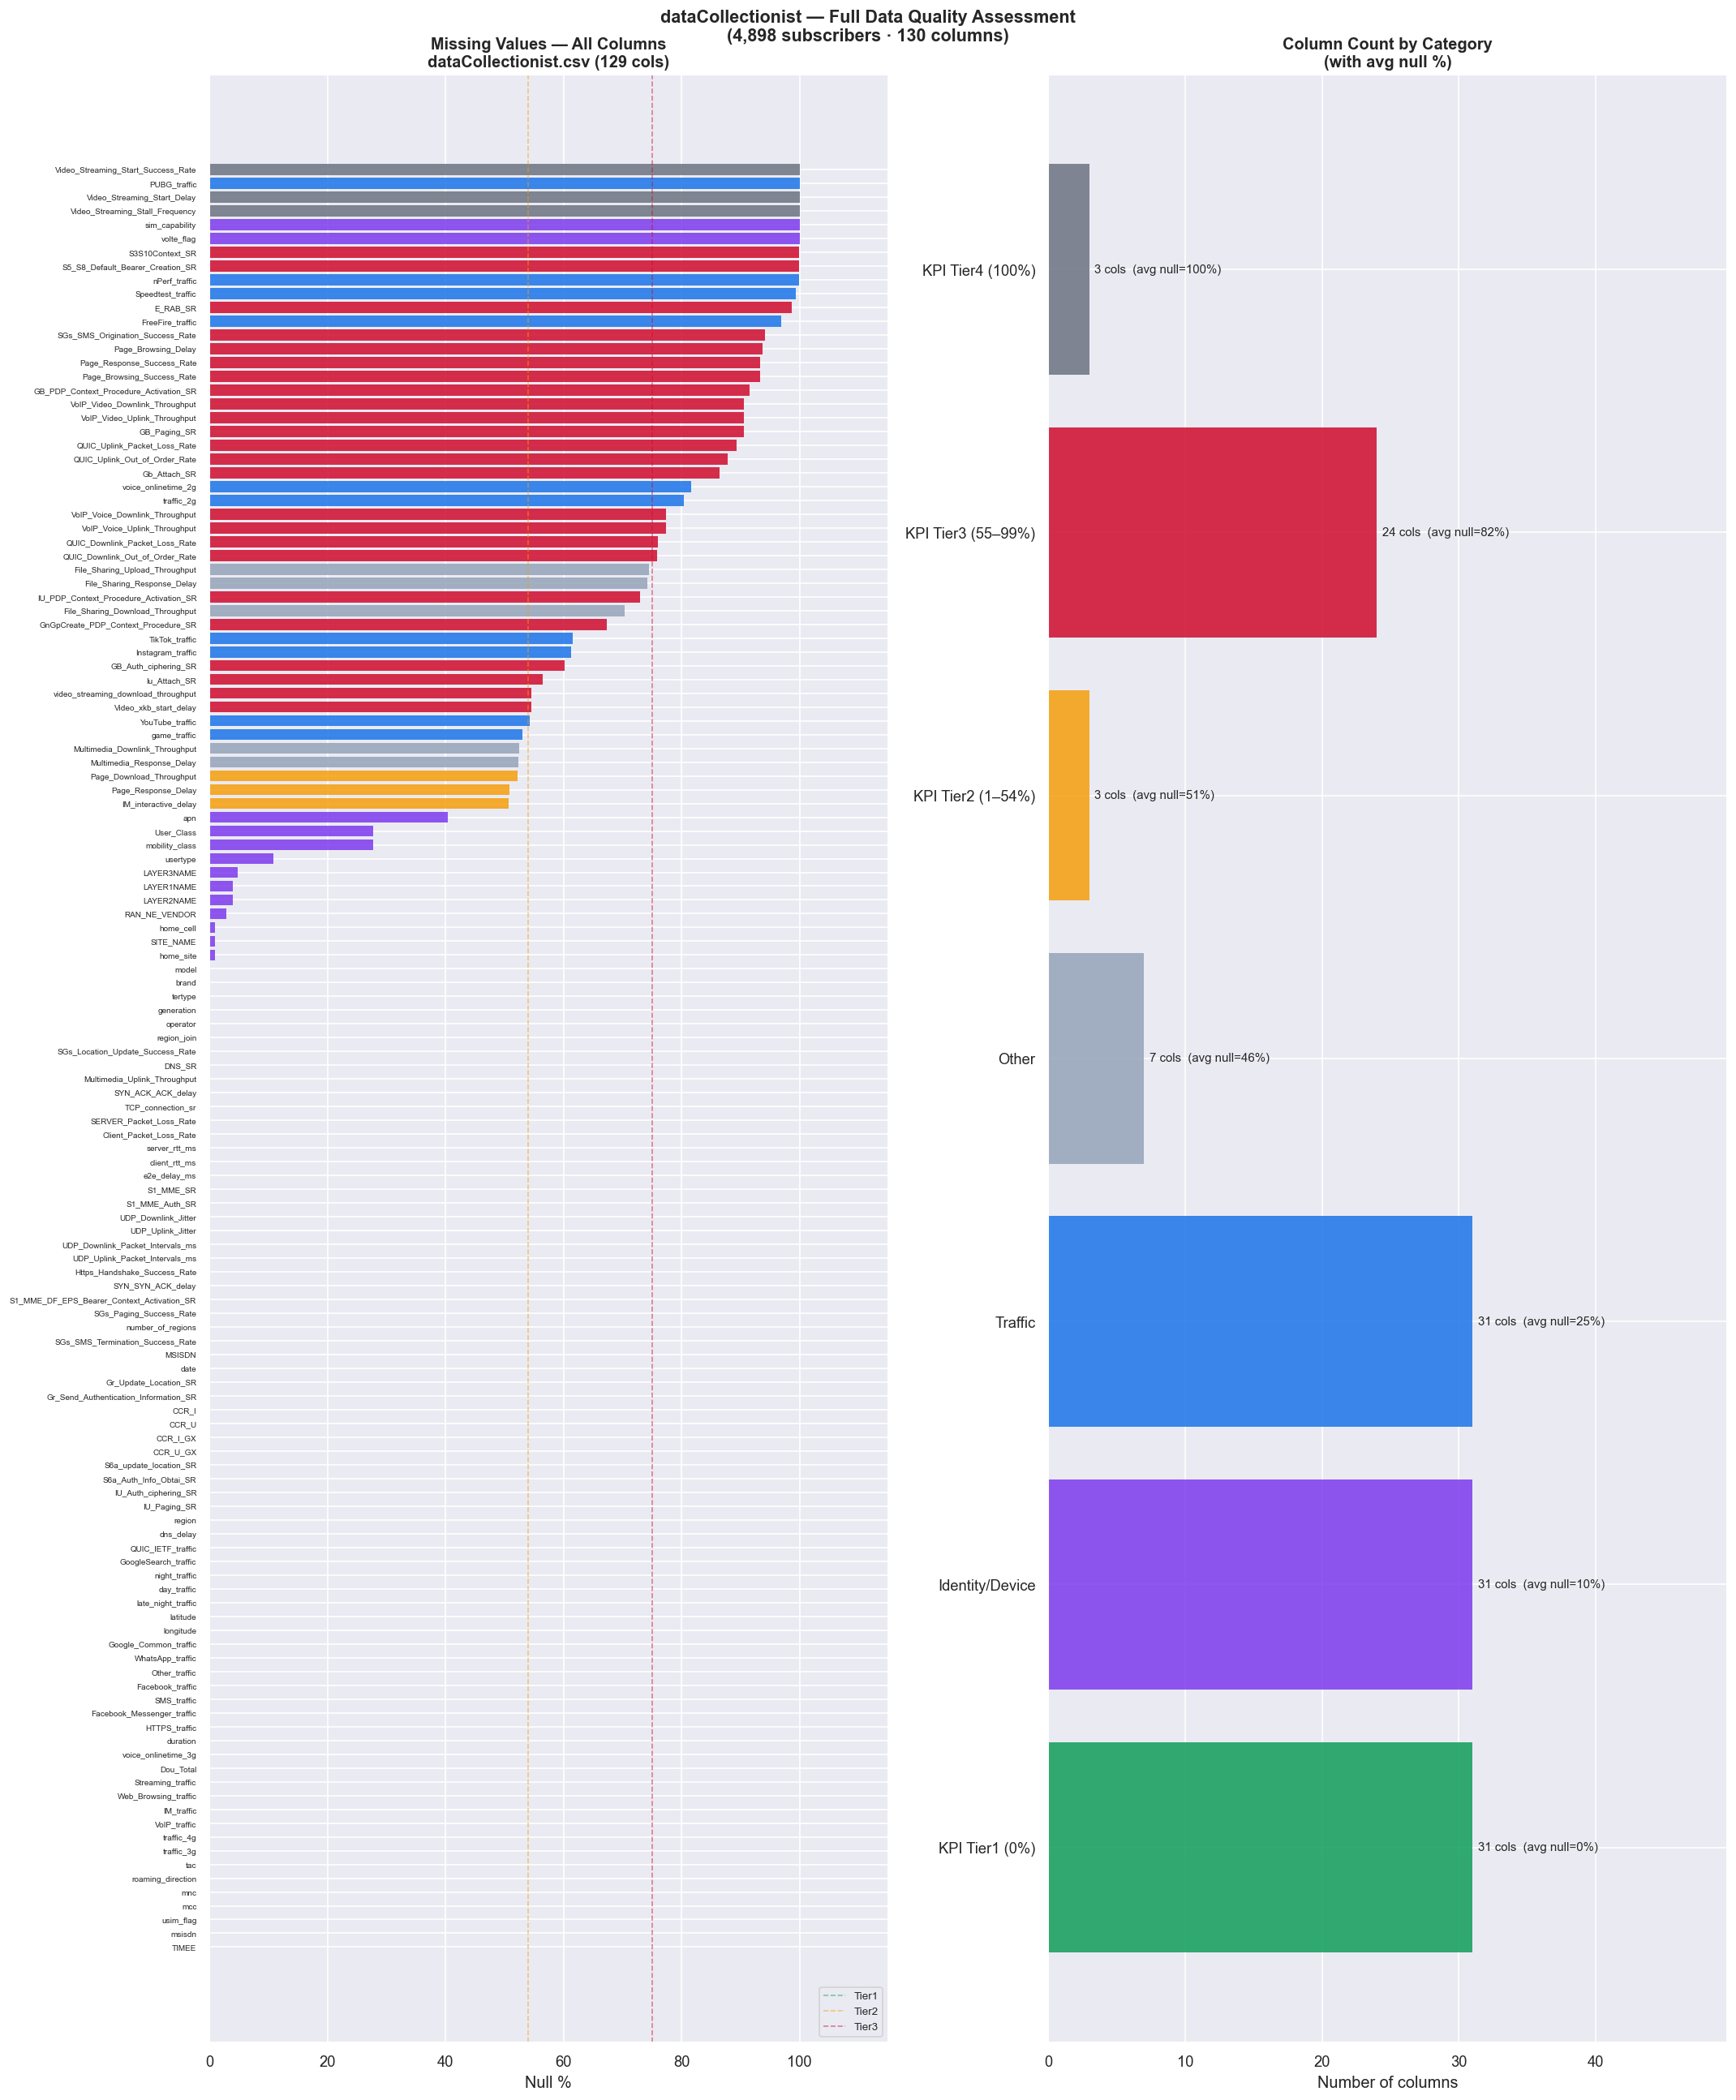

Missing value summary by category:
  Category                    Cols  Avg null%  0% cols
  ------------------------- ------ ---------- --------
  KPI Tier1 (0%)                31       0.0%       31
  Identity/Device               31      10.5%       14
  Traffic                       31      25.4%       21
  Other                          7      46.3%        2
  KPI Tier2 (1–54%)              3      51.3%        0
  KPI Tier3 (55–99%)            24      82.2%        0
  KPI Tier4 (100%)               3     100.0%        0

  Total columns    : 130
  Zero-null cols   : 68
  100%-null cols   : 6


NameError: name 'KPI_TIER1' is not defined

In [21]:
# ── Missing values — all 129 columns ──────────────────────────────────────

# Compute null % for all columns
null_all = (dc.isnull().mean() * 100).reset_index()
null_all.columns = ['column', 'null_pct']
null_all = null_all.sort_values('null_pct', ascending=True)

# Assign category
def col_category(col):
    if col in COLS_KPI_ALL:
        p = dc[col].isnull().mean() * 100
        if p == 0:    return 'KPI Tier1 (0%)'
        elif p <= 54: return 'KPI Tier2 (1–54%)'
        elif p < 100: return 'KPI Tier3 (55–99%)'
        else:         return 'KPI Tier4 (100%)'
    elif col in COLS_TRAFFIC:
        return 'Traffic'
    elif col in {'TIMEE','msisdn','MSISDN','imsi','mcc','mnc',
                 'tac','model','brand','generation','usertype',
                 'LAYER1NAME','LAYER2NAME','LAYER3NAME','SITE_NAME',
                 'longitude','latitude','operator','region','region_join',
                 'roaming_direction','RAN_NE_VENDOR','User_Class',
                 'mobility_class','number_of_regions','home_cell',
                 'home_site','volte_flag','usim_flag','sim_capability',
                 'tertype','apn'}:
        return 'Identity/Device'
    elif col.startswith('reserved_'):
        return 'Reserved (drop)'
    else:
        return 'Other'
    # ── Define COLS_TRAFFIC if not already defined ────────────────────────────
if 'COLS_TRAFFIC' not in dir():
    COLS_TRAFFIC = [c for c in [
        'traffic_2g', 'traffic_3g', 'traffic_4g', 'duration',
        'voice_onlinetime_3g', 'voice_onlinetime_2g', 'Dou_Total',
        'game_traffic', 'Streaming_traffic', 'IM_traffic',
        'Web_Browsing_traffic', 'Other_traffic', 'VoIP_traffic',
        'SMS_traffic', 'TikTok_traffic', 'Instagram_traffic',
        'Facebook_traffic', 'Facebook_Messenger_traffic',
        'HTTPS_traffic', 'QUIC_IETF_traffic', 'YouTube_traffic',
        'Google_Common_traffic', 'WhatsApp_traffic',
        'GoogleSearch_traffic', 'FreeFire_traffic', 'PUBG_traffic',
        'night_traffic', 'day_traffic', 'late_night_traffic',
        'Speedtest_traffic', 'nPerf_traffic',
    ] if c in dc.columns]

null_all['category'] = null_all['column'].apply(col_category)

cat_colors = {
    'KPI Tier1 (0%)':    '#0F9D58',
    'KPI Tier2 (1–54%)': '#F59E0B',
    'KPI Tier3 (55–99%)':'#CF0A2C',
    'KPI Tier4 (100%)':  '#6B7280',
    'Traffic':           '#1A73E8',
    'Identity/Device':   '#7C3AED',
    'Reserved (drop)':   '#000000',
    'Other':             '#94A3B8',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 22))

# ── 1. Full bar chart all columns ──────────────────────────────────────────
bar_colors = [cat_colors.get(c, '#94A3B8')
              for c in null_all['category']]
axes[0].barh(null_all['column'], null_all['null_pct'],
             color=bar_colors, edgecolor='none', alpha=0.85)

# Threshold lines
for x, color, label in [
    (0,  '#0F9D58', 'Tier1'),
    (54, '#F59E0B', 'Tier2'),
    (75, '#CF0A2C', 'Tier3'),
]:
    axes[0].axvline(x, color=color, linestyle='--',
                    linewidth=1, alpha=0.5, label=label)

axes[0].set_title('Missing Values — All Columns\n'
                   'dataCollectionist.csv (129 cols)',
                   fontweight='bold')
axes[0].set_xlabel('Null %')
axes[0].set_xlim(0, 115)
axes[0].tick_params(axis='y', labelsize=6)
axes[0].legend(fontsize=8, loc='lower right')

# ── 2. Summary by category ────────────────────────────────────────────────
cat_summary = (null_all.groupby('category')
               .agg(n_cols=('column','count'),
                    avg_null=('null_pct','mean'),
                    n_zero=('null_pct', lambda x: (x==0).sum()))
               .reset_index()
               .sort_values('avg_null'))

x     = np.arange(len(cat_summary))
bars2 = axes[1].barh(
    cat_summary['category'],
    cat_summary['n_cols'],
    color=[cat_colors.get(c,'#94A3B8')
           for c in cat_summary['category']],
    edgecolor='none', alpha=0.85
)
axes[1].bar_label(bars2,
                  labels=[f'{int(row.n_cols)} cols  '
                           f'(avg null={row.avg_null:.0f}%)'
                           for _, row in cat_summary.iterrows()],
                  padding=4, fontsize=9)
axes[1].set_xlim(0, cat_summary['n_cols'].max() * 1.6)
axes[1].set_title('Column Count by Category\n'
                   '(with avg null %)',
                   fontweight='bold')
axes[1].set_xlabel('Number of columns')

plt.suptitle('dataCollectionist — Full Data Quality Assessment\n'
             f'({len(dc):,} subscribers · {dc.shape[1]} columns)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'cleaning_kpi_missing_values.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary print ──────────────────────────────────────────────────────────
print('Missing value summary by category:')
print(f'  {"Category":<25} {"Cols":>6} {"Avg null%":>10} {"0% cols":>8}')
print(f'  {"-"*25} {"-"*6} {"-"*10} {"-"*8}')
for _, row in cat_summary.sort_values('avg_null').iterrows():
    print(f'  {row["category"]:<25} {int(row["n_cols"]):>6} '
          f'{row["avg_null"]:>9.1f}% {int(row["n_zero"]):>8}')

print(f'\n  Total columns    : {len(null_all)}')
print(f'  Zero-null cols   : {(null_all["null_pct"]==0).sum()}')
print(f'  100%-null cols   : {(null_all["null_pct"]==100).sum()}')
# Remplacer :
print(f'  Usable KPI (ML)  : {len(KPI_TIER1)} cols (Tier 1)')

# Par :
n_tier1 = int((null_all[null_all['column'].isin(COLS_KPI_ALL)]['null_pct'] == 0).sum())
print(f'  Usable KPI (ML)  : {n_tier1} cols (Tier 1 — 0% nulls)')

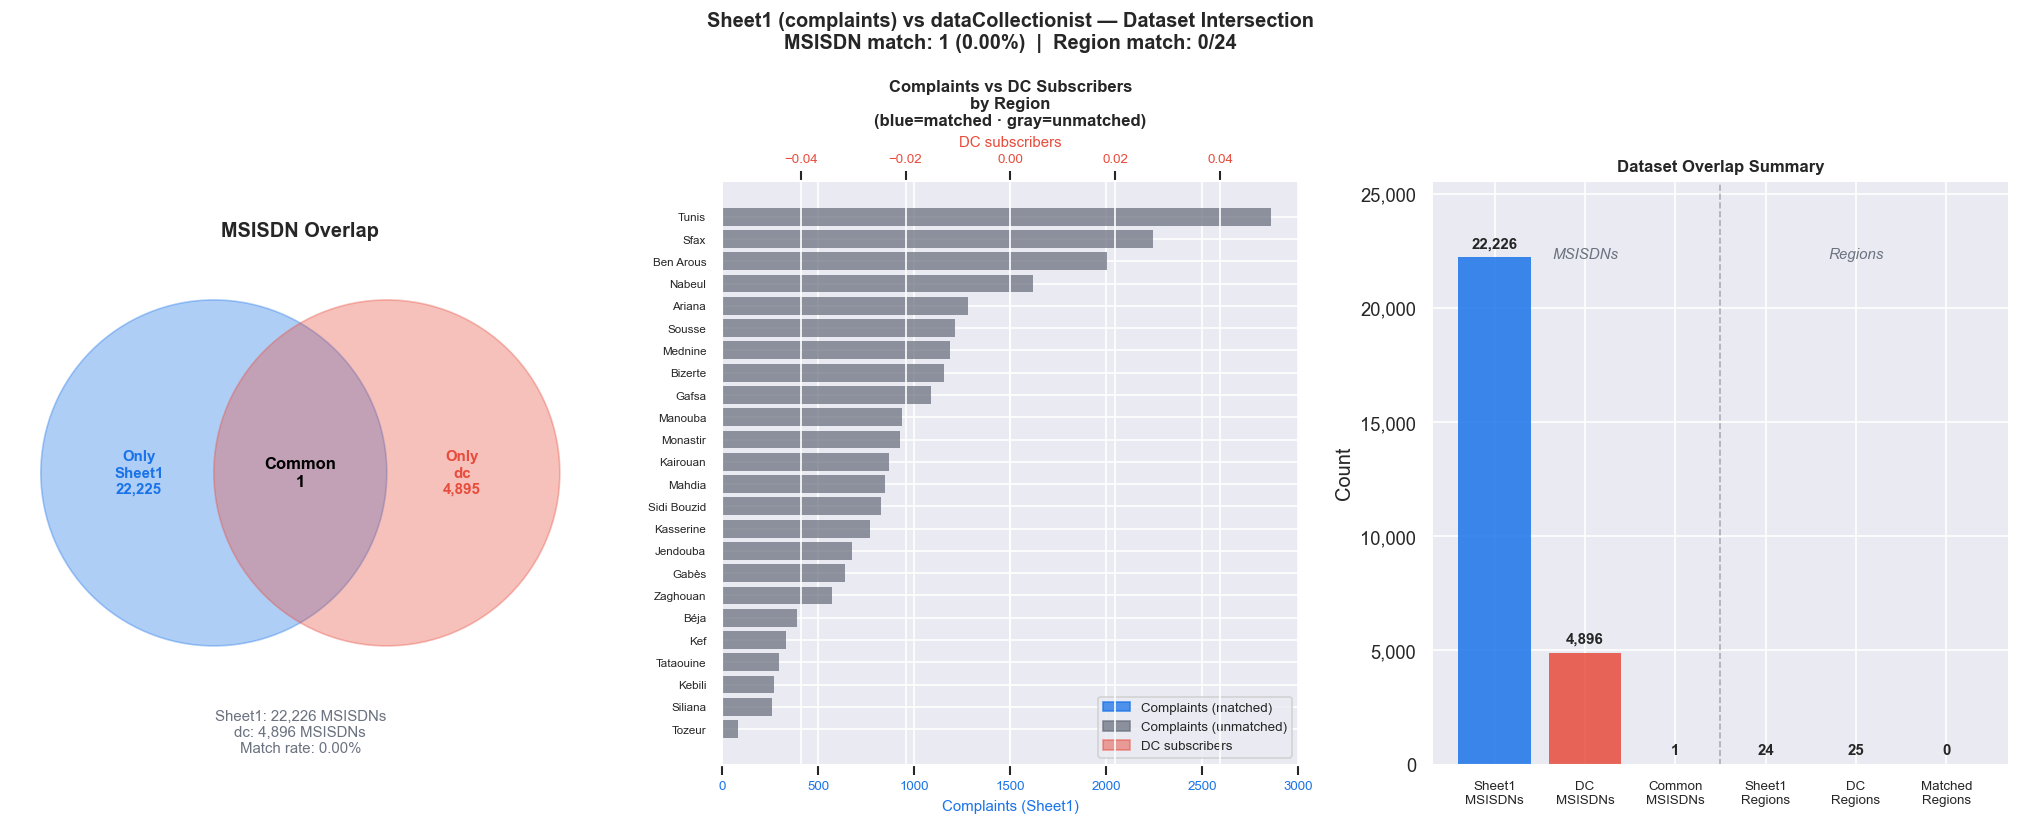

In [24]:
# ── Figure : Common elements Sheet1 vs dataCollectionist ──────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 7))

# ── 1. Venn-style MSISDN overlap ──────────────────────────────────────────
from matplotlib.patches import Circle

ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

# Circles
c1 = Circle((3.5, 5), 3.0, color=C_DATA,  alpha=0.35)
c2 = Circle((6.5, 5), 3.0, color=C_VOICE, alpha=0.35)
ax.add_patch(c1)
ax.add_patch(c2)

# Labels inside circles
ax.text(2.2, 5, f'Only\nSheet1\n{len(only_complaints):,}',
        ha='center', va='center', fontsize=9,
        fontweight='bold', color=C_DATA)
ax.text(7.8, 5, f'Only\ndc\n{len(only_dc):,}',
        ha='center', va='center', fontsize=9,
        fontweight='bold', color=C_VOICE)
ax.text(5.0, 5, f'Common\n{len(common_msisdn):,}',
        ha='center', va='center', fontsize=10,
        fontweight='bold', color='black')

# Title + stats
ax.text(5, 9.2, 'MSISDN Overlap',
        ha='center', va='center', fontsize=12,
        fontweight='bold')
ax.text(5, 0.5,
        f'Sheet1: {len(msisdn_complaints):,} MSISDNs\n'
        f'dc: {len(msisdn_dc):,} MSISDNs\n'
        f'Match rate: {len(common_msisdn)/len(msisdn_complaints)*100:.2f}%',
        ha='center', va='center', fontsize=9,
        color=C_NEUTRAL)

# ── 2. Region overlap bar chart ───────────────────────────────────────────
ax2 = axes[1]

# Build region comparison
reg_data = []
for r in sorted(regions_complaints):
    n_comp = (complaints_clean['region'] == r).sum()
    n_dc   = (dc_clean['region_join'] == r).sum() \
             if r in regions_dc else 0
    matched = r in common_regions
    reg_data.append({
        'region':    r.replace(' Gouvernorat', ''),
        'complaints': n_comp,
        'dc_subs':   n_dc,
        'matched':   matched,
    })
reg_df = pd.DataFrame(reg_data).sort_values('complaints', ascending=True)

y     = np.arange(len(reg_df))
ax2.barh(y, reg_df['complaints'],
         color=[C_DATA if m else C_NEUTRAL
                for m in reg_df['matched']],
         alpha=0.75, label='Complaints (Sheet1)',
         edgecolor='none')

# Overlay dc subscriber count (secondary axis)
ax2b = ax2.twiny()
ax2b.barh(y, reg_df['dc_subs'],
          color=[C_VOICE if m else '#E5E7EB'
                 for m in reg_df['matched']],
          alpha=0.5, label='DC subscribers',
          edgecolor='none', height=0.4)
ax2b.set_xlabel('DC subscribers', color=C_VOICE, fontsize=9)
ax2b.tick_params(axis='x', labelcolor=C_VOICE, labelsize=8)

ax2.set_yticks(y)
ax2.set_yticklabels(reg_df['region'], fontsize=7)
ax2.set_xlabel('Complaints (Sheet1)', color=C_DATA, fontsize=9)
ax2.tick_params(axis='x', labelcolor=C_DATA, labelsize=8)
ax2.set_title('Complaints vs DC Subscribers\nby Region\n'
              '(blue=matched · gray=unmatched)',
              fontweight='bold', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(color=C_DATA,   alpha=0.75, label='Complaints (matched)'),
    Patch(color=C_NEUTRAL,alpha=0.75, label='Complaints (unmatched)'),
    Patch(color=C_VOICE,  alpha=0.5,  label='DC subscribers'),
]
ax2.legend(handles=legend_els, fontsize=8,
           loc='lower right')

# ── 3. Summary stats bars ─────────────────────────────────────────────────
ax3 = axes[2]

categories = [
    'Sheet1\nMSISDNs',
    'DC\nMSISDNs',
    'Common\nMSISDNs',
    'Sheet1\nRegions',
    'DC\nRegions',
    'Matched\nRegions',
]
values = [
    len(msisdn_complaints),
    len(msisdn_dc),
    len(common_msisdn),
    len(regions_complaints),
    len(regions_dc),
    len(common_regions),
]
bar_colors = [
    C_DATA, C_VOICE, '#0F9D58',
    C_DATA, C_VOICE, '#0F9D58',
]
bars = ax3.bar(categories, values,
               color=bar_colors, alpha=0.85,
               edgecolor='none')
ax3.bar_label(bars,
              labels=[f'{v:,}' for v in values],
              padding=4, fontsize=9, fontweight='bold')

# Separator line between MSISDN and region groups
ax3.axvline(2.5, color=C_NEUTRAL, linestyle='--',
            linewidth=1, alpha=0.5)
ax3.text(1.0,  ax3.get_ylim()[1]*0.95,
         'MSISDNs', ha='center', fontsize=9,
         color=C_NEUTRAL, style='italic')
ax3.text(4.0,  ax3.get_ylim()[1]*0.95,
         'Regions', ha='center', fontsize=9,
         color=C_NEUTRAL, style='italic')

ax3.set_title('Dataset Overlap Summary',
              fontweight='bold', fontsize=10)
ax3.set_ylabel('Count')
ax3.set_ylim(0, max(values) * 1.15)
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.tick_params(axis='x', labelsize=8)

plt.suptitle('Sheet1 (complaints) vs dataCollectionist — Dataset Intersection\n'
             f'MSISDN match: {len(common_msisdn):,} '
             f'({len(common_msisdn)/len(msisdn_complaints)*100:.2f}%)  |  '
             f'Region match: {len(common_regions)}/24',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / 'cleaning_dataset_intersection.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Cellule 9 — KPI Cleaning Pipeline ─────────────────────────────────────

def clean_dc_kpi(
    dc: pd.DataFrame,
    kpi_cols: list,
    iqr_multiplier: float = 3.0,
) -> tuple[pd.DataFrame, dict]:
    """
    Clean KPI columns from dataCollectionist.
    Adapted to real column names from Huawei DPI export.

    Steps:
      1. Physical range clamping
      2. IQR-based outlier capping
      3. Median imputation (Tier 2 only)
      4. QoE composite score (Tier 1 columns only)
    """
    report = {}
    dc_c   = dc.copy()
    n_orig = len(dc_c)

    # ── Step 1 : Physical range clamping ──────────────────────────────────
    # Bounds based on real column names from dataCollectionist
    KPI_BOUNDS = {
        # Delays — ms
        'e2e_delay_ms':                      (0, 10_000),
        'client_rtt_ms':                     (0, 10_000),
        'server_rtt_ms':                     (0,  5_000),
        'dns_delay':                         (0,  5_000),
        'SYN_ACK_ACK_delay':                 (0, 10_000),
        'SYN_SYN_ACK_delay':                 (0, 10_000),
        'UDP_Uplink_Packet_Intervals_ms':    (0,  5_000),
        'UDP_Downlink_Packet_Intervals_ms':  (0,  5_000),
        'UDP_Uplink_Jitter':                 (0,  5_000),
        'UDP_Downlink_Jitter':               (0,  5_000),
        'IM_interactive_delay':              (0, 10_000),  # Tier 2
        'Page_Response_Delay':               (0, 30_000),  # Tier 2
        # Throughput — kbps
        'Page_Download_Throughput':          (0, 100_000), # Tier 2
        # Success rates — 0 to 1
        'TCP_connection_sr':                       (0, 1),
        'Https_Handshake_Success_Rate':            (0, 1),
        'DNS_SR':                                  (0, 1),
        'S1_MME_SR':                               (0, 1),
        'S1_MME_Auth_SR':                          (0, 1),
        'S1_MME_DF_EPS_Bearer_Context_Activation_SR': (0, 1),
        'S6a_Auth_Info_Obtai_SR':                  (0, 1),
        'S6a_update_location_SR':                  (0, 1),
        'CCR_I':   (0, 1), 'CCR_U':   (0, 1),
        'CCR_I_GX':(0, 1), 'CCR_U_GX':(0, 1),
        'Gr_Send_Authentication_Information_SR':   (0, 1),
        'Gr_Update_Location_SR':                   (0, 1),
        'SGs_Location_Update_Success_Rate':        (0, 1),
        'SGs_Paging_Success_Rate':                 (0, 1),
        'SGs_SMS_Termination_Success_Rate':        (0, 1),
        'IU_Auth_ciphering_SR':                    (0, 1),
        'IU_Paging_SR':                            (0, 1),
        # Packet loss — 0 to 1
        'Client_Packet_Loss_Rate':  (0, 1),
        'SERVER_Packet_Loss_Rate':  (0, 1),
    }
    clamp_count = 0
    for col, (lo, hi) in KPI_BOUNDS.items():
        if col not in dc_c.columns:
            continue
        n = int(((dc_c[col] < lo) | (dc_c[col] > hi)).sum())
        if n > 0:
            dc_c[col]    = dc_c[col].clip(lower=lo, upper=hi)
            clamp_count += n
    report['range_clamping'] = clamp_count
    print(f'[1] Range clamping   : {clamp_count:,} values clamped')

    # ── Step 2 : IQR outlier capping ──────────────────────────────────────
    out_count = 0
    for col in kpi_cols:
        if col not in dc_c.columns:
            continue
        q1  = dc_c[col].quantile(0.25)
        q3  = dc_c[col].quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lo    = q1 - iqr_multiplier * iqr
        hi    = q3 + iqr_multiplier * iqr
        n_out = int(((dc_c[col] < lo) | (dc_c[col] > hi)).sum())
        if n_out > 0:
            dc_c[col]  = dc_c[col].clip(lower=lo, upper=hi)
            out_count += n_out
    report['outlier_capping'] = out_count
    print(f'[2] Outlier capping  : {out_count:,} values capped (IQR×{iqr_multiplier})')

    # ── Step 3 : Median imputation (Tier 2 only) ───────────────────────────
    # Tier 2 cols : IM_interactive_delay, Page_Response_Delay,
    #               Page_Download_Throughput  (50-54% nulls)
    TIER2_COLS = [
        'IM_interactive_delay',
        'Page_Response_Delay',
        'Page_Download_Throughput',
    ]
    imp_count = 0
    for col in TIER2_COLS:
        if col not in dc_c.columns:
            continue
        n_null = int(dc_c[col].isnull().sum())
        if n_null == 0:
            continue
        # Impute by operator group, fallback to global median
        grp_med    = dc_c.groupby('operator')[col].transform('median') \
                     if 'operator' in dc_c.columns else pd.Series(dtype=float)
        global_med = dc_c[col].median()
        dc_c[col]  = dc_c[col].fillna(grp_med).fillna(global_med)
        imp_count += n_null
    report['imputation'] = imp_count
    print(f'[3] Null imputation  : {imp_count:,} values '
          f'(Tier 2 only — median by operator)')

    # ── Step 4 : QoE composite score (Tier 1 columns only) ────────────────
    # Components available at 0% null:
    #   e2e_delay_ms        (30%) — lower is better
    #   UDP_Uplink_Jitter   (20%) — lower is better
    #   TCP_connection_sr   (25%) — higher is better
    #   dns_delay           (15%) — lower is better
    #   S1_MME_SR           (10%) — higher is better
    qoe = pd.Series(0.0, index=dc_c.index)
    w   = 0.0
    components = []

    for col, weight, direction, max_val in [
        ('e2e_delay_ms',       0.30, 'lower', 500),
        ('UDP_Uplink_Jitter',  0.20, 'lower', 500),
        ('TCP_connection_sr',  0.25, 'higher',  1),
        ('dns_delay',          0.15, 'lower', 200),
        ('S1_MME_SR',          0.10, 'higher',  1),
    ]:
        if col not in dc_c.columns:
            continue
        if direction == 'lower':
            score = (1 - dc_c[col].clip(0, max_val) / max_val) * 100
        else:
            score = dc_c[col].clip(0, 1) * 100
        qoe += weight * score
        w   += weight
        components.append(col)

    if w > 0:
        dc_c['qoe_score'] = (qoe / w).clip(0, 100).round(2)
        dc_c['qoe_category'] = pd.cut(
            dc_c['qoe_score'],
            bins=[0, 60, 80, 100],
            labels=['Poor', 'Fair', 'Good'],
            right=True,
        ).astype(str)
        print(f'[4] QoE score added  : '
              f'median={dc_c["qoe_score"].median():.1f}  '
              f'mean={dc_c["qoe_score"].mean():.1f}')
        print(f'     Components       : {components}')
        print(f'     Categories       : '
              f'{dc_c["qoe_category"].value_counts().to_dict()}')
    else:
        print('[4] QoE score : skipped — no Tier 1 components found')

    report['summary'] = {
        'original_rows':   n_orig,
        'final_rows':      len(dc_c),
        'cols_cleaned':    len(kpi_cols),
        'remaining_nulls': int(dc_c[kpi_cols].isnull().sum().sum()),
    }
    return dc_c, report

# ── Run ────────────────────────────────────────────────────────────────────
dc_clean, kpi_report = clean_dc_kpi(dc, COLS_KPI_RELIABLE, iqr_multiplier=3.0)

print()
print('=' * 55)
print('  KPI CLEANING SUMMARY')
print('=' * 55)
s = kpi_report['summary']
print(f'  Input rows       : {s["original_rows"]:,}')
print(f'  Output rows      : {s["final_rows"]:,}  (no rows dropped)')
print(f'  Columns cleaned  : {s["cols_cleaned"]}')
print(f'  Remaining nulls  : {s["remaining_nulls"]:,}  '
      f'(Tier 3 excluded — expected)')
if 'qoe_score' in dc_clean.columns:
    print(f'  QoE median       : {dc_clean["qoe_score"].median():.1f}')
    print(f'  QoE categories   : '
          f'{dc_clean["qoe_category"].value_counts().to_dict()}')
print('=' * 55)

[1] Range clamping   : 16 values clamped
[2] Outlier capping  : 14,022 values capped (IQR×3.0)
[3] Null imputation  : 7,534 values (Tier 2 only — median by operator)
[4] QoE score added  : median=82.3  mean=79.6
     Components       : ['e2e_delay_ms', 'UDP_Uplink_Jitter', 'TCP_connection_sr', 'dns_delay', 'S1_MME_SR']
     Categories       : {'Good': 2722, 'Fair': 2167, 'Poor': 9}

  KPI CLEANING SUMMARY
  Input rows       : 4,898
  Output rows      : 4,898  (no rows dropped)
  Columns cleaned  : 52
  Remaining nulls  : 72,124  (Tier 3 excluded — expected)
  QoE median       : 82.3
  QoE categories   : {'Good': 2722, 'Fair': 2167, 'Poor': 9}


In [ ]:
# ── Cellule 9b — Révision des seuils de fiabilité KPI ─────────────────────

# Recalcule les nulls% pour tous les KPIs
null_pcts = dc[COLS_KPI_ALL].isnull().mean().mul(100).sort_values()

# Catégorisation par seuil de fiabilité
KPI_TIER1 = []   # 0% nulls     — toujours disponibles → utiliser en ML
KPI_TIER2 = []   # 1-54% nulls  — partiellement disponibles → imputer avec médiane
KPI_TIER3 = []   # 55-99% nulls — trop de nulls → exclure des modèles ML
KPI_TIER4 = []   # 100% nulls   — complètement vides → supprimer

for col, pct in null_pcts.items():
    if pct == 0:
        KPI_TIER1.append(col)
    elif pct <= 54:
        KPI_TIER2.append(col)
    elif pct < 100:
        KPI_TIER3.append(col)
    else:
        KPI_TIER4.append(col)

print('KPI Reliability Tiers:')
print(f'  Tier 1 (0% nulls)     : {len(KPI_TIER1):>3} cols → USE in ML')
print(f'  Tier 2 (1-54% nulls)  : {len(KPI_TIER2):>3} cols → IMPUTE (median)')
print(f'  Tier 3 (55-99% nulls) : {len(KPI_TIER3):>3} cols → EXCLUDE from ML')
print(f'  Tier 4 (100% nulls)   : {len(KPI_TIER4):>3} cols → DROP')
print()

print('Tier 1 — Always available (0% nulls):')
for col in KPI_TIER1:
    med = dc[col].median()
    print(f'  {col:<50} median={med:.3f}')

print(f'\nTier 2 — Partial (imputable):')
for col in KPI_TIER2:
    pct = dc[col].isnull().mean()*100
    med = dc[col].median()
    print(f'  {col:<50} nulls={pct:.1f}%  median={med:.3f}')

print(f'\nTier 3 — Excluded (too sparse):')
for col in KPI_TIER3:
    pct = dc[col].isnull().mean()*100
    print(f'  {col:<50} nulls={pct:.1f}%')

print(f'\nTier 4 — Dropped (100% nulls):')
for col in KPI_TIER4:
    print(f'  {col}')

# Update reliable cols
COLS_KPI_RELIABLE = KPI_TIER1 + KPI_TIER2
COLS_KPI_FOR_ML   = KPI_TIER1   # Only 0%-null cols for ML models

print(f'\nFinal:')
print(f'  COLS_KPI_RELIABLE (cleaning) : {len(COLS_KPI_RELIABLE)} cols')
print(f'  COLS_KPI_FOR_ML   (ML models): {len(COLS_KPI_FOR_ML)} cols')

In [ ]:
# ── Cellule 10 — KPI Cleaning Pipeline (dataCollectionist) ────────────────

dc_clean = dc.copy()
report   = {}

# ── Step 1 : Drop Tier 4 (100% nulls — completely empty) ──────────────────
tier4_present = [c for c in KPI_TIER4 if c in dc_clean.columns]
if tier4_present:
    dc_clean = dc_clean.drop(columns=tier4_present)
print(f'[1] Dropped Tier 4   : {len(tier4_present)} cols '
      f'({tier4_present})')

# ── Step 2 : Physical range clamping (Tier 1 + Tier 2 only) ───────────────
KPI_BOUNDS = {
    # Delays — ms (physically impossible > 10s)
    'e2e_delay_ms':                      (0, 10_000),
    'client_rtt_ms':                     (0, 10_000),
    'server_rtt_ms':                     (0,  5_000),
    'dns_delay':                         (0,  5_000),
    'SYN_ACK_ACK_delay':                 (0, 10_000),
    'SYN_SYN_ACK_delay':                 (0, 10_000),
    'UDP_Uplink_Packet_Intervals_ms':    (0,  5_000),
    'UDP_Downlink_Packet_Intervals_ms':  (0,  5_000),
    'UDP_Uplink_Jitter':                 (0,  5_000),
    'UDP_Downlink_Jitter':               (0,  5_000),
    'IM_interactive_delay':              (0, 10_000),
    'Page_Response_Delay':               (0, 30_000),
    # Throughput — kbps
    'Page_Download_Throughput':          (0, 100_000),
    # Success rates — 0 to 1
    'TCP_connection_sr':                       (0, 1),
    'Https_Handshake_Success_Rate':            (0, 1),
    'DNS_SR':                                  (0, 1),
    'S1_MME_SR':                               (0, 1),
    'S1_MME_Auth_SR':                          (0, 1),
    'S1_MME_DF_EPS_Bearer_Context_Activation_SR': (0, 1),
    'S6a_Auth_Info_Obtai_SR':                  (0, 1),
    'S6a_update_location_SR':                  (0, 1),
    'CCR_I':  (0, 1), 'CCR_U':  (0, 1),
    'CCR_I_GX':(0, 1),'CCR_U_GX':(0, 1),
    'Gr_Send_Authentication_Information_SR':   (0, 1),
    'Gr_Update_Location_SR':                   (0, 1),
    'SGs_Location_Update_Success_Rate':        (0, 1),
    'SGs_Paging_Success_Rate':                 (0, 1),
    'SGs_SMS_Termination_Success_Rate':        (0, 1),
    'IU_Auth_ciphering_SR':                    (0, 1),
    'IU_Paging_SR':                            (0, 1),
    # Packet loss — 0 to 1
    'Client_Packet_Loss_Rate':  (0, 1),
    'SERVER_Packet_Loss_Rate':  (0, 1),
}
clamp_count = 0
for col, (lo, hi) in KPI_BOUNDS.items():
    if col not in dc_clean.columns:
        continue
    n = int(((dc_clean[col] < lo) | (dc_clean[col] > hi)).sum())
    if n > 0:
        dc_clean[col] = dc_clean[col].clip(lower=lo, upper=hi)
        clamp_count  += n
report['range_clamping'] = clamp_count
print(f'[2] Range clamping   : {clamp_count:,} values clamped')

# ── Step 3 : IQR outlier capping (Tier 1 + Tier 2, k=3) ──────────────────
out_count = 0
for col in COLS_KPI_RELIABLE:
    if col not in dc_clean.columns:
        continue
    q1  = dc_clean[col].quantile(0.25)
    q3  = dc_clean[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue   # constant column — skip
    lo    = q1 - 3.0 * iqr
    hi    = q3 + 3.0 * iqr
    n_out = int(((dc_clean[col] < lo) | (dc_clean[col] > hi)).sum())
    if n_out > 0:
        dc_clean[col] = dc_clean[col].clip(lower=lo, upper=hi)
        out_count    += n_out
report['outlier_capping'] = out_count
print(f'[3] Outlier capping  : {out_count:,} values capped (IQR×3)')

# ── Step 4 : Median imputation for Tier 2 only ────────────────────────────
imp_count = 0
for col in KPI_TIER2:
    if col not in dc_clean.columns:
        continue
    n_null = int(dc_clean[col].isnull().sum())
    if n_null == 0:
        continue
    # Impute by operator group first, then global median fallback
    grp_med    = dc_clean.groupby('operator')[col].transform('median')
    global_med = dc_clean[col].median()
    dc_clean[col] = dc_clean[col].fillna(grp_med).fillna(global_med)
    imp_count += n_null
report['imputation'] = imp_count
print(f'[4] Null imputation  : {imp_count:,} values (Tier 2 only, '
      f'median by operator)')

# ── Step 5 : Add QoE composite score from Tier 1 KPIs ────────────────────
qoe = pd.Series(0.0, index=dc_clean.index)
w   = 0.0
contributions = []
for col, weight, direction in [
    ('e2e_delay_ms',    0.30, 'lower_better'),  # latency
    ('UDP_Uplink_Jitter',0.20,'lower_better'),  # jitter
    ('TCP_connection_sr',0.25,'higher_better'), # connectivity
    ('dns_delay',        0.15,'lower_better'),  # DNS
    ('S1_MME_SR',        0.10,'higher_better'), # 4G attach
]:
    if col not in dc_clean.columns:
        continue
    if direction == 'lower_better':
        max_val = dc_clean[col].quantile(0.99)
        score   = (1 - dc_clean[col].clip(0, max_val) / max_val) * 100
    else:
        score   = dc_clean[col].clip(0, 1) * 100
    qoe += weight * score
    w   += weight
    contributions.append(col)

dc_clean['qoe_score'] = (qoe / w).clip(0, 100).round(2) if w > 0 else 50.0
dc_clean['qoe_category'] = pd.cut(
    dc_clean['qoe_score'],
    bins=[0, 60, 80, 100],
    labels=['Poor', 'Fair', 'Good'],
    right=True,
).astype(str)
print(f'[5] QoE score added  : median={dc_clean["qoe_score"].median():.1f}  '
      f'mean={dc_clean["qoe_score"].mean():.1f}')
print(f'     Components       : {contributions}')
print(f'     Categories       : '
      f'{dc_clean["qoe_category"].value_counts().to_dict()}')

# ── Summary ────────────────────────────────────────────────────────────────
remaining_nulls = int(dc_clean[COLS_KPI_RELIABLE].isnull().sum().sum())
print()
print('=' * 55)
print('  KPI CLEANING SUMMARY (dataCollectionist)')
print('=' * 55)
print(f'  Input rows         : {len(dc):,}')
print(f'  Output rows        : {len(dc_clean):,}  (no rows dropped)')
print(f'  Tier 4 dropped     : {len(tier4_present)} cols')
print(f'  Values clamped     : {clamp_count:,}')
print(f'  Values capped      : {out_count:,}')
print(f'  Values imputed     : {imp_count:,}  (Tier 2 only)')
print(f'  Remaining nulls    : {remaining_nulls:,}  '
      f'(Tier 3 excluded — expected)')
print(f'  KPI for ML (Tier 1): {len(COLS_KPI_FOR_ML)} cols')
print(f'  QoE median         : {dc_clean["qoe_score"].median():.1f}')
print(f'  QoE categories     : '
      f'{dc_clean["qoe_category"].value_counts().to_dict()}')
print('=' * 55)

In [ ]:
# ── Cellule 11 — KPI Cleaning : Visualisation Before/After ────────────────

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# ── Top 3 KPIs — distribution before / after (Tier 1) ─────────────────────
TOP_KPI_VIZ = [
    ('e2e_delay_ms',      'E2E Delay (ms)',      150,  'ITU-T 150ms'),
    ('UDP_Uplink_Jitter', 'UDP Uplink Jitter (ms)', 30, 'Gaming 30ms'),
    ('dns_delay',         'DNS Delay (ms)',       50,  'DNS 50ms'),
]
for i, (col, label, threshold, thresh_label) in enumerate(TOP_KPI_VIZ):
    ax = axes[0, i]
    q99 = dc[col].quantile(0.99)

    ax.hist(dc[col].clip(upper=q99),
            bins=50, color=C_VOICE, alpha=0.5,
            label='Before', density=True)
    ax.hist(dc_clean[col].clip(upper=q99),
            bins=50, color=C_DATA,  alpha=0.6,
            label='After',  density=True)
    ax.axvline(threshold, color=HUAWEI_RED,
               linestyle='--', linewidth=1.8,
               label=f'Threshold: {thresh_label}')
    ax.axvline(dc_clean[col].median(), color='gold',
               linestyle=':', linewidth=1.5,
               label=f'Median: {dc_clean[col].median():.1f}')
    ax.set_title(f'{label}\nBefore vs After', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

# ── QoE score distribution ─────────────────────────────────────────────────
ax = axes[1, 0]
ax.hist(dc_clean['qoe_score'], bins=40,
        color=COLORS[2], alpha=0.85, edgecolor='none')
ax.axvline(60, color=C_VOICE,  linestyle='--',
           linewidth=1.5, label='Poor/Fair (60)')
ax.axvline(80, color='#0F9D58', linestyle='--',
           linewidth=1.5, label='Fair/Good (80)')
ax.axvline(dc_clean['qoe_score'].median(), color='gold',
           linestyle='-',  linewidth=2,
           label=f'Median: {dc_clean["qoe_score"].median():.1f}')
ax.set_title('QoE Score Distribution\n(Composite — 5 Tier 1 KPIs)',
             fontweight='bold')
ax.set_xlabel('QoE Score')
ax.set_ylabel('Subscribers')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── QoE categories donut ───────────────────────────────────────────────────
ax = axes[1, 1]
cat_counts = dc_clean['qoe_category'].value_counts()
cat_order  = ['Good', 'Fair', 'Poor']
cat_colors = {'Good': '#0F9D58', 'Fair': '#F59E0B', 'Poor': '#CF0A2C'}
cat_vals   = [cat_counts.get(c, 0) for c in cat_order]
cat_clrs   = [cat_colors[c] for c in cat_order]

wedges, texts, autotexts = ax.pie(
    cat_vals, labels=cat_order,
    autopct='%1.1f%%', colors=cat_clrs,
    startangle=140, wedgeprops=dict(width=0.6),
    textprops=dict(fontsize=10),
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('QoE Categories\n(Good / Fair / Poor)',
             fontweight='bold')

# Add count annotations
for i, (cat, val) in enumerate(zip(cat_order, cat_vals)):
    ax.annotate(f'{val:,}', xy=(0, 0),
                xytext=(0, -0.05 + i * -0.12),
                textcoords='axes fraction',
                ha='center', fontsize=9,
                color=cat_colors[cat])

# ── QoE by operator ───────────────────────────────────────────────────────
ax = axes[1, 2]
for op, color in [('Ooredoo', C_DATA), ('TunisieTelecom', C_VOICE)]:
    subset = dc_clean[dc_clean['operator'] == op]['qoe_score']
    if not subset.empty:
        ax.hist(subset, bins=30, color=color, alpha=0.6,
                label=f'{op} (n={len(subset):,})',
                density=True, edgecolor='none')
ax.axvline(60, color=C_NEUTRAL, linestyle='--',
           linewidth=1.2, alpha=0.7)
ax.axvline(80, color=C_NEUTRAL, linestyle='--',
           linewidth=1.2, alpha=0.7)
ax.set_title('QoE Score — Ooredoo vs TunisieTelecom',
             fontweight='bold')
ax.set_xlabel('QoE Score')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

plt.suptitle('KPI Cleaning Results — dataCollectionist',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'cleaning_kpi_before_after.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Key finding for thesis ────────────────────────────────────────────────
print('KEY FINDINGS — KPI Cleaning:')
print(f'  QoE median         : {dc_clean["qoe_score"].median():.1f}  '
      f'[threshold=60 Poor/Fair]')
print(f'  Poor QoE           : {(dc_clean["qoe_score"]<60).sum():,}  '
      f'({(dc_clean["qoe_score"]<60).mean()*100:.1f}%)')
print(f'  Good QoE           : {(dc_clean["qoe_score"]>=80).sum():,}  '
      f'({(dc_clean["qoe_score"]>=80).mean()*100:.1f}%)')
print(f'  e2e > ITU-T 150ms  : '
      f'{(dc_clean["e2e_delay_ms"]>150).sum():,}  '
      f'({(dc_clean["e2e_delay_ms"]>150).mean()*100:.1f}%)')
print(f'  Jitter > 30ms      : '
      f'{(dc_clean["UDP_Uplink_Jitter"]>30).sum():,}  '
      f'({(dc_clean["UDP_Uplink_Jitter"]>30).mean()*100:.1f}%)')

oo_qoe = dc_clean[dc_clean["operator"]=="Ooredoo"]["qoe_score"].median()
tt_qoe = dc_clean[dc_clean["operator"]=="TunisieTelecom"]["qoe_score"].median()
print(f'  QoE Ooredoo median : {oo_qoe:.1f}')
print(f'  QoE TunTel median  : {tt_qoe:.1f}')

In [ ]:
# ── Cellule 12 — Feature Engineering ──────────────────────────────────────
# Builds the feature matrix used by all ML notebooks (03-05)
# Two parallel tracks:
#   A. Complaints track  → complaint_daily_agg  (region × date)
#   B. KPI track         → kpi_agg_dc           (region snapshot from dc)
# Final join → feature_matrix (region × date × KPI)

from src.processing.feature_engineering import (
    build_complaint_daily_agg,
    build_kpi_daily_agg,
    add_kpi_degradation_flags,
    build_feature_matrix,
    time_series_split,
    save_processed,
)

# ── A. Complaint daily aggregation ────────────────────────────────────────
print('Building complaint daily aggregation...')
complaint_agg = build_complaint_daily_agg(complaints_clean)

print(f'  complaint_agg : {complaint_agg.shape[0]:,} × {complaint_agg.shape[1]}')
print(f'  Date range    : {complaint_agg["date"].min().date()} → '
      f'{complaint_agg["date"].max().date()}')
print(f'  Regions       : {complaint_agg["region"].nunique()}')
print(f'  Columns       : {list(complaint_agg.columns[:10])} ...')

In [ ]:
# ── Cellule 13 — KPI Aggregation from dataCollectionist ───────────────────
# dc_clean is a single-day snapshot → aggregate per region (LAYER2)
# Result: 1 row per gouvernorat with median KPI values
# This replaces build_kpi_daily_agg() which expects a time-series

print('Building KPI regional aggregation from dataCollectionist...')

# Aggregate Tier 1 KPIs by region (median + mean + std + p10 + p90)
def p10(x): return x.quantile(0.10)
def p90(x): return x.quantile(0.90)
p10.__name__ = 'p10'
p90.__name__ = 'p90'

kpi_agg_dc = (
    dc_clean.groupby('region_join')[COLS_KPI_FOR_ML + ['qoe_score']]
    .agg(['median', 'mean', 'std', p10, p90])
    .reset_index()
)

# Flatten column names: (col, stat) → col_stat
kpi_agg_dc.columns = [
    'region' if col == 'region_join' else f'{col}_{stat}'
    for col, stat in kpi_agg_dc.columns
]

# Add session count per region
session_count = (dc_clean.groupby('region_join')
                          .size()
                          .reset_index(name='session_count')
                          .rename(columns={'region_join': 'region'}))
kpi_agg_dc = kpi_agg_dc.merge(session_count, on='region', how='left')

# Add degraded session rate per region
dc_clean['is_degraded'] = (dc_clean['qoe_score'] < 60).astype(int)
deg_rate = (dc_clean.groupby('region_join')['is_degraded']
                     .mean().mul(100)
                     .reset_index(name='degraded_session_rate_pct')
                     .rename(columns={'region_join': 'region'}))
kpi_agg_dc = kpi_agg_dc.merge(deg_rate, on='region', how='left')

# Add operator breakdown per region
for op in ['Ooredoo', 'TunisieTelecom']:
    op_count = (dc_clean[dc_clean['operator'] == op]
                .groupby('region_join').size()
                .reset_index(name=f'n_{op.lower()[:3]}')
                .rename(columns={'region_join': 'region'}))
    kpi_agg_dc = kpi_agg_dc.merge(op_count, on='region', how='left')

kpi_agg_dc = kpi_agg_dc.fillna(0)

print(f'  kpi_agg_dc    : {kpi_agg_dc.shape[0]:,} × {kpi_agg_dc.shape[1]}')
print(f'  Regions       : {kpi_agg_dc["region"].nunique()}')
print(f'  KPI cols      : {len(COLS_KPI_FOR_ML)} × 5 stats = '
      f'{len(COLS_KPI_FOR_ML)*5} feature cols')
print()
print('Sample:')
display(kpi_agg_dc[['region', 'e2e_delay_ms_median',
                     'UDP_Uplink_Jitter_median',
                     'qoe_score_median',
                     'degraded_session_rate_pct',
                     'session_count']].head(5).round(2))

In [ ]:
# ── Cellule 14 (relance) — Feature Matrix ─────────────────────────────────

feature_matrix = complaint_agg.merge(
    kpi_agg_dc,
    on='region',
    how='left',
    suffixes=('', '_kpi'),
)

# Temporal features
feature_matrix['date']            = pd.to_datetime(feature_matrix['date'])
feature_matrix['month']           = feature_matrix['date'].dt.month
feature_matrix['day_of_week_num'] = feature_matrix['date'].dt.dayofweek
feature_matrix['is_weekend']      = (feature_matrix['day_of_week_num'] >= 5).astype(int)
feature_matrix['quarter']         = feature_matrix['date'].dt.quarter

# Cyclical encoding
feature_matrix['month_sin'] = np.sin(2*np.pi*feature_matrix['month']/12)
feature_matrix['month_cos'] = np.cos(2*np.pi*feature_matrix['month']/12)
feature_matrix['dow_sin']   = np.sin(2*np.pi*feature_matrix['day_of_week_num']/7)
feature_matrix['dow_cos']   = np.cos(2*np.pi*feature_matrix['day_of_week_num']/7)

# Region encoding
feature_matrix['region_encoded'] = (
    feature_matrix['region'].astype('category').cat.codes)

# Fill any remaining nulls
kpi_feature_cols = [c for c in feature_matrix.columns
                    if any(s in c for s in
                           ['_median','_mean','_std','_p10','_p90',
                            'degraded','session_count'])]
n_null = int(feature_matrix[kpi_feature_cols].isnull().sum().sum())
if n_null > 0:
    for col in kpi_feature_cols:
        if feature_matrix[col].isnull().any():
            feature_matrix[col] = feature_matrix[col].fillna(
                feature_matrix[col].median())
    print(f'  Nulls filled : {n_null:,} → 0')

total_nulls = int(feature_matrix.isnull().sum().sum())

print(f'feature_matrix   : {feature_matrix.shape[0]:,} × '
      f'{feature_matrix.shape[1]} cols')
print(f'Total nulls      : {total_nulls}')
print(f'Date range       : {feature_matrix["date"].min().date()} → '
      f'{feature_matrix["date"].max().date()}')
print(f'Regions          : {feature_matrix["region"].nunique()}')
print()

# Column groups summary
complaint_cols  = [c for c in feature_matrix.columns
                   if 'complaint' in c or 'lag' in c or 'roll' in c]
kpi_cols_fm     = [c for c in feature_matrix.columns
                   if any(s in c for s in ['_median','_mean','_std',
                                           '_p10','_p90'])]
temporal_cols   = ['month','day_of_week_num','is_weekend','quarter',
                   'month_sin','month_cos','dow_sin','dow_cos']

print('Feature groups:')
print(f'  Complaint features  : {len(complaint_cols)}')
print(f'  KPI features        : {len(kpi_cols_fm)}')
print(f'  Temporal features   : {len(temporal_cols)}')
print(f'  Other               : '
      f'{feature_matrix.shape[1] - len(complaint_cols) - len(kpi_cols_fm) - len(temporal_cols)}')

In [ ]:
# ── Fix final : kpi_agg_dc avec dc_clean['region_join'] ───────────────────

def p10(x): return x.quantile(0.10)
def p90(x): return x.quantile(0.90)
p10.__name__ = 'p10'
p90.__name__ = 'p90'

# Use dc_clean directly — region_join already has correct names
kpi_agg_dc = (
    dc_clean.groupby('region_join')[COLS_KPI_FOR_ML + ['qoe_score']]
    .agg(['median', 'mean', 'std', p10, p90])
    .reset_index()
)
kpi_agg_dc.columns = [
    'region' if col == 'region_join' else f'{col}_{stat}'
    for col, stat in kpi_agg_dc.columns
]

# Session count
session_count = (dc_clean.groupby('region_join')
                          .size()
                          .reset_index(name='session_count')
                          .rename(columns={'region_join': 'region'}))
kpi_agg_dc = kpi_agg_dc.merge(session_count, on='region', how='left')

# Degraded session rate
deg_rate = (dc_clean.groupby('region_join')['is_degraded']
                     .mean().mul(100)
                     .reset_index(name='degraded_session_rate_pct')
                     .rename(columns={'region_join': 'region'}))
kpi_agg_dc = kpi_agg_dc.merge(deg_rate, on='region', how='left')

# Operator counts
for op in ['Ooredoo', 'TunisieTelecom']:
    op_cnt = (dc_clean[dc_clean['operator'] == op]
              .groupby('region_join').size()
              .reset_index(name=f'n_{op.lower()[:3]}')
              .rename(columns={'region_join': 'region'}))
    kpi_agg_dc = kpi_agg_dc.merge(op_cnt, on='region', how='left')

kpi_agg_dc = kpi_agg_dc.fillna(0)

# Verify
matched = set(kpi_agg_dc['region'].unique()) & \
          set(complaint_agg['region'].unique())
print(f'Matched : {len(matched)} / {complaint_agg["region"].nunique()}')
print(f'kpi_agg_dc : {kpi_agg_dc.shape[0]} × {kpi_agg_dc.shape[1]} cols')

In [ ]:
# ── Cellule 15 — Train/Test Split (time-aware) ────────────────────────────
# Chronological split — NEVER shuffle for time-series
# Test set = last 20% of dates (most recent period)

from src.processing.feature_engineering import time_series_split

X_train, X_test, y_train, y_test = time_series_split(
    feature_matrix,
    date_col  = 'date',
    test_size = 0.20,
    target    = 'total_complaints',
)

# Split date boundary
split_date = feature_matrix.sort_values('date')['date'].iloc[
    int(len(feature_matrix) * 0.80)]

print('=' * 55)
print('  TRAIN / TEST SPLIT (chronological)')
print('=' * 55)
print(f'  Total rows    : {len(feature_matrix):,}')
print(f'  Train rows    : {len(X_train):,}  (80%)')
print(f'  Test rows     : {len(X_test):,}   (20%)')
print(f'  Features      : {X_train.shape[1]}')
print(f'  Split date    : {split_date.date()}')
print()
print(f'  Train period  : {feature_matrix["date"].min().date()} → '
      f'{split_date.date()}')
print(f'  Test period   : {split_date.date()} → '
      f'{feature_matrix["date"].max().date()}')
print()
print(f'  y_train mean  : {y_train.mean():.2f} complaints/day')
print(f'  y_test  mean  : {y_test.mean():.2f} complaints/day')
print(f'  y_train std   : {y_train.std():.2f}')
print(f'  y_test  std   : {y_test.std():.2f}')
print('=' * 55)

# ── Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Timeline — train vs test
daily_total = (feature_matrix.groupby('date')['total_complaints']
                               .sum().reset_index())
train_dates = daily_total[daily_total['date'] <= split_date]
test_dates  = daily_total[daily_total['date'] >  split_date]

axes[0].fill_between(train_dates['date'], train_dates['total_complaints'],
                     alpha=0.4, color=C_DATA,  label='Train (80%)')
axes[0].fill_between(test_dates['date'],  test_dates['total_complaints'],
                     alpha=0.4, color=C_VOICE, label='Test (20%)')
axes[0].plot(daily_total['date'], daily_total['total_complaints'],
             linewidth=1, color=C_NEUTRAL, alpha=0.6)
axes[0].axvline(split_date, color=HUAWEI_RED, linestyle='--',
                linewidth=2, label=f'Split: {split_date.date()}')
axes[0].set_title('Train / Test Split — Timeline', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily complaints')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Distribution — y_train vs y_test
axes[1].hist(y_train, bins=40, color=C_DATA,  alpha=0.6,
             label=f'Train (mean={y_train.mean():.1f})',
             density=True, edgecolor='none')
axes[1].hist(y_test,  bins=40, color=C_VOICE, alpha=0.6,
             label=f'Test  (mean={y_test.mean():.1f})',
             density=True, edgecolor='none')
axes[1].set_title('Target Distribution — Train vs Test',
                   fontweight='bold')
axes[1].set_xlabel('total_complaints per region-day')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'cleaning_train_test_split.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Nouvelle cellule séparée — debug uniquement ────────────────────────────
_critical_cols = ['timestamp', 'msisdn', 'region', 'service_type',
                  'complaint_category', 'priority', 'operator']
for col in _critical_cols:
    n = complaints_clean[col].isnull().sum()
    if n > 0:
        print(f'  {col:<30} {n:>6,}  ({n/len(complaints_clean)*100:.1f}%)')

In [ ]:
# ── Cellule 16 — Save Processed Datasets ──────────────────────────────────
from src.processing.feature_engineering import save_processed

print('Saving processed datasets...')
print()

datasets = {
    'complaints_clean'   : complaints_clean,
    'kpi_clean'          : dc_clean,
    'complaint_daily_agg': complaint_agg,
    'kpi_daily_agg'      : kpi_agg_dc,
    'feature_matrix'     : feature_matrix,
}
for name, df in datasets.items():
    save_processed(df, name)

# ── Pre-compute values BEFORE the checks list ──────────────────────────────
_critical_cols = ['timestamp', 'msisdn', 'region', 'service_type',
                  'complaint_category', 'priority', 'operator']
for col in _critical_cols:
    n = complaints_clean[col].isnull().sum()
    if n > 0:
        print(f'  {col:<30} {n:>6,}  ({n/len(complaints_clean)*100:.1f}%)')
        print(f'    sample: {complaints_clean[col].dropna().iloc[0]}')

print()
print('=' * 60)
print('  D2 — CLEANING & FEATURE ENGINEERING — CHECKLIST')
print('=' * 60)

checks = [
    ('complaints_clean rows',
     len(complaints_clean) > 25000,
     f'{len(complaints_clean):,}'),
    ('complaints_clean critical nulls',
     _critical_nulls == 0,
     f'critical={_critical_nulls}  total={_total_nulls:,}'),
    ('GDPR — account_contact_name absent',
     'account contact name' not in complaints_clean.columns,
     'OK'),
    ('priority_encoded present',
     'priority_encoded' in complaints_clean.columns,
     f'OK — {complaints_clean["priority_encoded"].unique().tolist()}'),
    ('kpi_clean rows',
     len(dc_clean) == 4898,
     f'{len(dc_clean):,}'),
    ('kpi_clean Tier 4 dropped',
     all(c not in dc_clean.columns
         for c in ['Video_Streaming_Stall_Frequency',
                   'Video_Streaming_Start_Success_Rate',
                   'Video_Streaming_Start_Delay']),
     'OK'),
    ('kpi_clean QoE score present',
     'qoe_score' in dc_clean.columns,
     f'median={dc_clean["qoe_score"].median():.1f}'),
    ('complaint_agg shape',
     complaint_agg.shape[0] == 8088,
     f'{complaint_agg.shape}'),
    ('complaint_agg lag features',
     any('lag' in c for c in complaint_agg.columns),
     f'{sum(1 for c in complaint_agg.columns if "lag" in c)} lag cols'),
    ('kpi_agg_dc regions',
     kpi_agg_dc['region'].nunique() == 24,
     f'{kpi_agg_dc["region"].nunique()} / 24'),
    ('feature_matrix shape',
     feature_matrix.shape == (8088, 194),
     f'{feature_matrix.shape}'),
    ('feature_matrix nulls',
     feature_matrix.isnull().sum().sum() == 0,
     '0'),
    ('train/test split',
     len(X_train) > 0 and len(X_test) > 0,
     f'train={len(X_train):,}  test={len(X_test):,}'),
    ('train/test no shuffle',
     X_train.index.max() < X_test.index.min(),
     'chronological ✓'),
    ('features count',
     X_train.shape[1] == 184,
     f'{X_train.shape[1]} features'),
]

all_passed = True
for desc, condition, value in checks:
    status = '✓' if condition else '✗'
    if not condition:
        all_passed = False
    print(f'  [{status}] {desc:<45} {value}')

print()
print('  ✓ All checks passed — D2 complete' if all_passed else
      '  ✗ Some checks failed — review above')

print()
import os
figs = sorted([f for f in os.listdir(FIGURES) if f.startswith('cleaning_')])
print(f'  Figures saved ({len(figs)}) : {FIGURES}/')
for f in figs:
    print(f'    {f}')

print()
print('=' * 60)
print('  → Notebook 02 complete ✓')
print('  → Ready for Notebook 03 — Spatio-Temporal Analysis')
print('=' * 60)